# EquiRelief — Week 4: Evaluation & Demo

**This notebook contains:**
1. Full NLP pipeline evaluation (all 5 languages, all stages)
2. Full RL policy evaluation (reward, Gini, fairness, urgency response)
3. Ablation study re-run at 1000 episodes (corrected from Week 3)
4. Stress tests — imbalanced demand, isolated region, sudden emergency
5. End-to-end demo: raw multilingual messages → RL allocation decision
6. Result tables and publication-ready plots
7. Honest limitations section

**All numbers used here are the real outputs from Weeks 2 and 3:**
- NLP: Lang=100%, Region=81.7%, Resource F1=0.724/0.787, Urgency F1=0.588 (multilingual)
- RL: Reward 72→128 over 2000 ep, Gini 0.014→0.003, Var 0.00087→0.00004

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os, warnings
BASE = '/content/drive/MyDrive/Equi-Relief'  # fix: match your actual folder name
if f'{BASE}/notebooks' not in sys.path:
    sys.path.insert(0, f'{BASE}/notebooks')

os.environ['HF_HOME']                    = f'{BASE}/models/hf_cache'
os.environ['TRANSFORMERS_CACHE']         = f'{BASE}/models/hf_cache'
os.environ['HF_DATASETS_CACHE']          = f'{BASE}/models/hf_cache/datasets'
os.environ['SENTENCE_TRANSFORMERS_HOME'] = f'{BASE}/models/hf_cache/sentence_transformers'

import config, utils
utils.set_seed(config.SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Regions: {config.REGIONS}')

Mounted at /content/drive
Device : cuda
Regions: ['north', 'south', 'east', 'west', 'central']


In [ ]:
%%capture
!pip install -q transformers datasets sentence-transformers \
    gymnasium scikit-learn pandas numpy matplotlib seaborn tqdm
print('Done.')

In [ ]:
import json, random, math, re, time, warnings
from collections import deque, namedtuple, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import spaces
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'font.size'         : 10,
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2','#1098AD','#862E9C','#D9480F']

def section(t):
    print('\n' + '='*65)
    print(f'  {t}')
    print('='*65)

def savefig(name):
    p = f'{config.OUT_PLOTS}/{name}.png'
    plt.savefig(p, bbox_inches='tight', dpi=150)
    print(f'  saved -> {p}')

print('Imports OK.')

Imports OK.


---
# Part 1 — Rebuild all components from saved files

Week 4 loads everything from Drive — no re-training needed.

In [ ]:
section('Load all Week 2 and Week 3 outputs')

# ── NLP outputs ───────────────────────────────────────────────────────────
demand_raw   = utils.load_json(f'{config.OUT_DEMAND}/region_demand.json')
rl_results   = utils.load_json(f'{config.OUT_RESULTS}/rl_results.json')
curves_df    = pd.read_csv(f'{config.OUT_RESULTS}/training_curves.csv')
manual_test  = pd.DataFrame(utils.load_json(f'{config.TEST_SET}/combined_180.json'))
manual_test.rename(columns={'text':'tweet_text'}, inplace=True)

print('Loaded:')
print(f'  region_demand.json   : {len(demand_raw)} regions')
print(f'  rl_results.json      : {list(rl_results.keys())}')
print(f'  training_curves.csv  : {len(curves_df):,} episodes')
print(f'  manual test set      : {len(manual_test):,} samples')

# ── Reconstruct env constants ─────────────────────────────────────────────
REGIONS     = config.REGIONS
N           = config.N_REGIONS
RESOURCES   = ['food', 'water', 'medicine']
N_RESOURCES = 3
N_ACTIONS   = N_RESOURCES * N + 1   # 16
STATE_DIM   = N * 7 + 1             # 36
MAX_STEPS   = 200
MAX_WAIT    = 20.0

need_food     = np.array([demand_raw[r]['need']['food']     for r in REGIONS], dtype=np.float32)
need_water    = np.array([demand_raw[r]['need']['water']    for r in REGIONS], dtype=np.float32)
need_medicine = np.array([demand_raw[r]['need']['medicine'] for r in REGIONS], dtype=np.float32)
urgency_init  = np.array([demand_raw[r]['urgency']          for r in REGIONS], dtype=np.float32)
max_need      = max(need_food.max(), need_water.max(), need_medicine.max(), 1.0)
need_food_n   = need_food / max_need
need_water_n  = need_water / max_need
need_med_n    = need_medicine / max_need

print(f'\nDemand vector (from NLP pipeline):')
print(f'{"Region":<10} {"Food":>6} {"Water":>6} {"Med":>6} {"Urgency":>8}')
print('-'*42)
for r in REGIONS:
    d = demand_raw[r]
    print(f'{r:<10} {d["need"]["food"]:>6} {d["need"]["water"]:>6} {d["need"]["medicine"]:>6} {d["urgency"]:>8.2f}')


  Load all Week 2 and Week 3 outputs
Loaded:
  region_demand.json   : 5 regions
  rl_results.json      : ['training', 'policy_comparison', 'ablation', 'urgency_response', 'config']
  training_curves.csv  : 2,000 episodes
  manual test set      : 180 samples

Demand vector (from NLP pipeline):
Region       Food  Water    Med  Urgency
------------------------------------------
north          20      3     12     1.00
south          17     26      9     1.00
east           16      6      6     1.00
west           24      6      2     1.00
central        45      7     10     1.00


In [ ]:
# ── Rebuild EquiReliefEnv ─────────────────────────────────────────────────
from typing import Tuple

class EquiReliefEnv(gym.Env):
    metadata = {'render_modes': []}
    def __init__(self, need_food=need_food_n, need_water=need_water_n,
                 need_medicine=need_med_n, urgency_init=urgency_init,
                 reward_cfg=None, stochastic=True, seed=42):
        super().__init__()
        rc = reward_cfg or config.REWARD
        self.alpha = rc['alpha']; self.lam = rc['lam']
        self.beta  = rc['beta'];  self.delta = rc['delta']
        self.stochastic = stochastic
        self.np_random  = np.random.default_rng(seed)
        self.base_need  = np.stack([need_food, need_water, need_medicine], axis=1).astype(np.float32)
        self.urgency_init = urgency_init.astype(np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(STATE_DIM,), dtype=np.float32)
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.reset()

    def _decode_action(self, a):
        if a == N_ACTIONS-1: return -1,-1
        return a//N, a%N

    def _get_state(self):
        state, ratios = [], []
        for i in range(N):
            r = self.delivered[i].sum()/(self.need[i].sum()+1e-6)
            ratios.append(r)
            state.extend([float(np.clip(self.need[i,0],0,1)),
                          float(np.clip(self.need[i,1],0,1)),
                          float(np.clip(self.need[i,2],0,1)),
                          float(np.clip(self.resource[i],0,1)),
                          float(min(self.wait[i]/MAX_WAIT,1.0)),
                          float(np.clip(r,0,1)),
                          float(np.clip(self.urgency[i],0,1))])
        state.append(float(np.clip(np.var(ratios),0,1)))
        return np.array(state, dtype=np.float32)

    def _new_demand(self):
        if not self.stochastic: return np.zeros((N,3),dtype=np.float32)
        arr = self.np_random.poisson(lam=0.05, size=(N,3)).astype(np.float32)
        arr *= (self.base_need+0.1)
        return np.clip(arr/max_need, 0, 0.3)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None: self.np_random = np.random.default_rng(seed)
        self.need      = self.base_need.copy()
        self.resource  = np.ones(N, dtype=np.float32)
        self.wait      = np.zeros(N, dtype=np.float32)
        self.delivered = np.zeros((N,3), dtype=np.float32)
        self.urgency   = self.urgency_init.copy()
        self.step_count= 0
        return self._get_state(), {}

    def step(self, action):
        ri, regi = self._decode_action(action)
        self.step_count += 1
        reward = 0.0
        efficiency_gain = 0.0
        if ri >= 0:
            disp = min(self.resource[regi], self.need[regi,ri])
            nb   = self.need[regi,ri]
            self.need[regi,ri]      = max(0.0, nb-disp)
            self.delivered[regi,ri]+= disp
            self.resource[regi]     = max(0.0, self.resource[regi]-disp)
            efficiency_gain = disp/(nb+1e-6)
            reward += self.alpha*efficiency_gain
            reward += self.beta*self.urgency[regi]*efficiency_gain
            self.wait[regi] = 0.0
            self.resource[regi] = min(1.0, self.resource[regi]+0.3)
        ratios = [self.delivered[i].sum()/(self.need[i].sum()+self.delivered[i].sum()+1e-6) for i in range(N)]
        fp = float(np.var(ratios))
        reward -= self.lam*fp
        self.wait += 1.0
        if ri >= 0: self.wait[regi] = 0.0
        dp = float(np.mean(self.wait/MAX_WAIT))
        reward -= self.delta*dp
        for i in range(N):
            if self.need[i].sum() < 0.05:
                self.urgency[i] = max(0.0, self.urgency[i]-0.05)
        self.need = np.clip(self.need+self._new_demand(), 0, 1)
        done = self.step_count >= MAX_STEPS
        return self._get_state(), reward, done, False, {'fairness_var':fp,'ratios':ratios,'efficiency_gain':efficiency_gain}

print('EquiReliefEnv rebuilt OK.')

EquiReliefEnv rebuilt OK.


In [ ]:
# ── Rebuild DQNetwork ────────────────────────────────────────────────────
class DQNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(state_dim,hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden,hidden),   nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden,hidden//2), nn.ReLU())
        self.value_stream = nn.Sequential(nn.Linear(hidden//2,hidden//4), nn.ReLU(), nn.Linear(hidden//4,1))
        self.adv_stream   = nn.Sequential(nn.Linear(hidden//2,hidden//4), nn.ReLU(), nn.Linear(hidden//4,n_actions))
    def forward(self, x):
        f = self.features(x)
        v = self.value_stream(f)
        a = self.adv_stream(f)
        return v + a - a.mean(dim=1, keepdim=True)

# ── Load best trained model ───────────────────────────────────────────────
CKPT_PATH = f'{config.CKPT_DIR}/equirelief_dqn'
best_ckpt  = f'{CKPT_PATH}/best_policy.pt'

online_net = DQNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
ckpt       = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
online_net.load_state_dict(ckpt['online_state_dict'])
online_net.eval()

print(f'Model loaded from {best_ckpt}')
print(f'  steps_done : {ckpt["steps_done"]:,}')
print(f'  epsilon    : {ckpt["epsilon"]:.4f}')
print(f'  parameters : {sum(p.numel() for p in online_net.parameters()):,}')

# ── Baseline + EquiRelief policies ───────────────────────────────────────
def random_policy(state): return random.randint(0, N_ACTIONS-1)

def greedy_policy(state):
    best, best_a = -1.0, N_ACTIONS-1
    for ri in range(N_RESOURCES):
        for regi in range(N):
            b = state[regi*7+ri] * state[regi*7+3]
            if b > best: best, best_a = b, ri*N+regi
    return best_a

def equity_greedy_policy(state):
    best, best_a = -1.0, N_ACTIONS-1
    for ri in range(N_RESOURCES):
        for regi in range(N):
            need=state[regi*7+ri]; inv=state[regi*7+3]
            ratio=state[regi*7+5]+0.1; urg=state[regi*7+6]
            b = (need*(1+urg))/ratio*inv
            if b > best: best, best_a = b, ri*N+regi
    return best_a

def equirelief_policy(state):
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return int(online_net(s).argmax(dim=1).item())

ALL_POLICIES = {
    'Random'          : random_policy,
    'Greedy'          : greedy_policy,
    'Equity-Greedy'   : equity_greedy_policy,
    'EquiRelief (DQN)': equirelief_policy,
}
print('All policies ready.')

Model loaded from /content/drive/MyDrive/Equi-Relief/models/checkpoints/equirelief_dqn/best_policy.pt
  steps_done : 400,000
  epsilon    : 0.0500
  parameters : 126,801
All policies ready.


---
# Part 2 — NLP Pipeline Evaluation

Full evaluation table across all 5 languages using the saved test set results.

In [ ]:
section('NLP Pipeline — Evaluation Summary')

# Real numbers from Week 2 runs
nlp_results = {
    'stage2_lang_detection': {
        'overall': 1.000,
        'per_lang': {'en':1.0, 'hi':1.0, 'ta':1.0, 'hinglish':1.0, 'tanglish':1.0}
    },
    'stage6_7_region': {'accuracy': 0.817},
    'stage7_resource': {
        'f1_manual'     : 0.724,
        'f1_figureeight': 0.787,
    },
    'stage8_urgency': {
        'f1_english_test'  : 0.879,
        'f1_kerala_domain' : 0.829,
        'f1_multilingual'  : 0.588,
        'per_lang': {
            'en'      : 0.792,
            'hi'      : 0.688,
            'ta'      : 0.749,
            'hinglish': 0.517,
            'tanglish': 0.499,
        }
    }
}
utils.save_json(nlp_results, f'{config.OUT_RESULTS}/nlp_results.json')

# Print summary table
print(f'{"Stage":<30} {"Metric":<25} {"Score":>8}')
print('-'*65)
print(f'{"Stage 2 — Language Detection":<30} {"Accuracy (180 samples)":<25} {"100.0%":>8}')
print(f'{"Stage 6/7 — Region Detection":<30} {"Accuracy (180 samples)":<25} {"81.7%":>8}')
print(f'{"Stage 7 — Resource Extraction":<30} {"F1 macro (manual 180)":<25} {"0.724":>8}')
print(f'{"Stage 7 — Resource Extraction":<30} {"F1 macro (Figure Eight)":<25} {"0.787":>8}')
print(f'{"Stage 8 — Urgency (English)":<30} {"F1 macro (CrisisNLP test)":<25} {"0.879":>8}')
print(f'{"Stage 8 — Urgency (Kerala)":<30} {"F1 macro (domain test)":<25} {"0.829":>8}')
print(f'{"Stage 8 — Urgency (Multilingual)":<30} {"F1 macro (5 languages)":<25} {"0.588":>8}')

print(f'\nPer-language urgency F1:')
print(f'{"Language":<15} {"F1":>8} {"N":>6} {"Interpretation"}')
print('-'*60)
interps = {
    'en'      : 'Supervised training',
    'hi'      : 'Zero-shot (Devanagari script)',
    'ta'      : 'Zero-shot (Tamil script)',
    'hinglish': 'Zero-shot (romanized code-mixed)',
    'tanglish': 'Zero-shot (romanized code-mixed)',
}
n_per_lang = {'en':20,'hi':20,'ta':20,'hinglish':60,'tanglish':60}
for lang, f1 in nlp_results['stage8_urgency']['per_lang'].items():
    print(f'{lang:<15} {f1:>8.3f} {n_per_lang[lang]:>6}   {interps[lang]}')


  NLP Pipeline — Evaluation Summary
Saved -> /content/drive/MyDrive/Equi-Relief/outputs/results/nlp_results.json
Stage                          Metric                       Score
-----------------------------------------------------------------
Stage 2 — Language Detection   Accuracy (180 samples)      100.0%
Stage 6/7 — Region Detection   Accuracy (180 samples)       81.7%
Stage 7 — Resource Extraction  F1 macro (manual 180)        0.724
Stage 7 — Resource Extraction  F1 macro (Figure Eight)      0.787
Stage 8 — Urgency (English)    F1 macro (CrisisNLP test)    0.879
Stage 8 — Urgency (Kerala)     F1 macro (domain test)       0.829
Stage 8 — Urgency (Multilingual) F1 macro (5 languages)       0.588

Per-language urgency F1:
Language              F1      N Interpretation
------------------------------------------------------------
en                 0.792     20   Supervised training
hi                 0.688     20   Zero-shot (Devanagari script)
ta                 0.749     20   Zero


  NLP Evaluation — Publication plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_nlp_summary.png


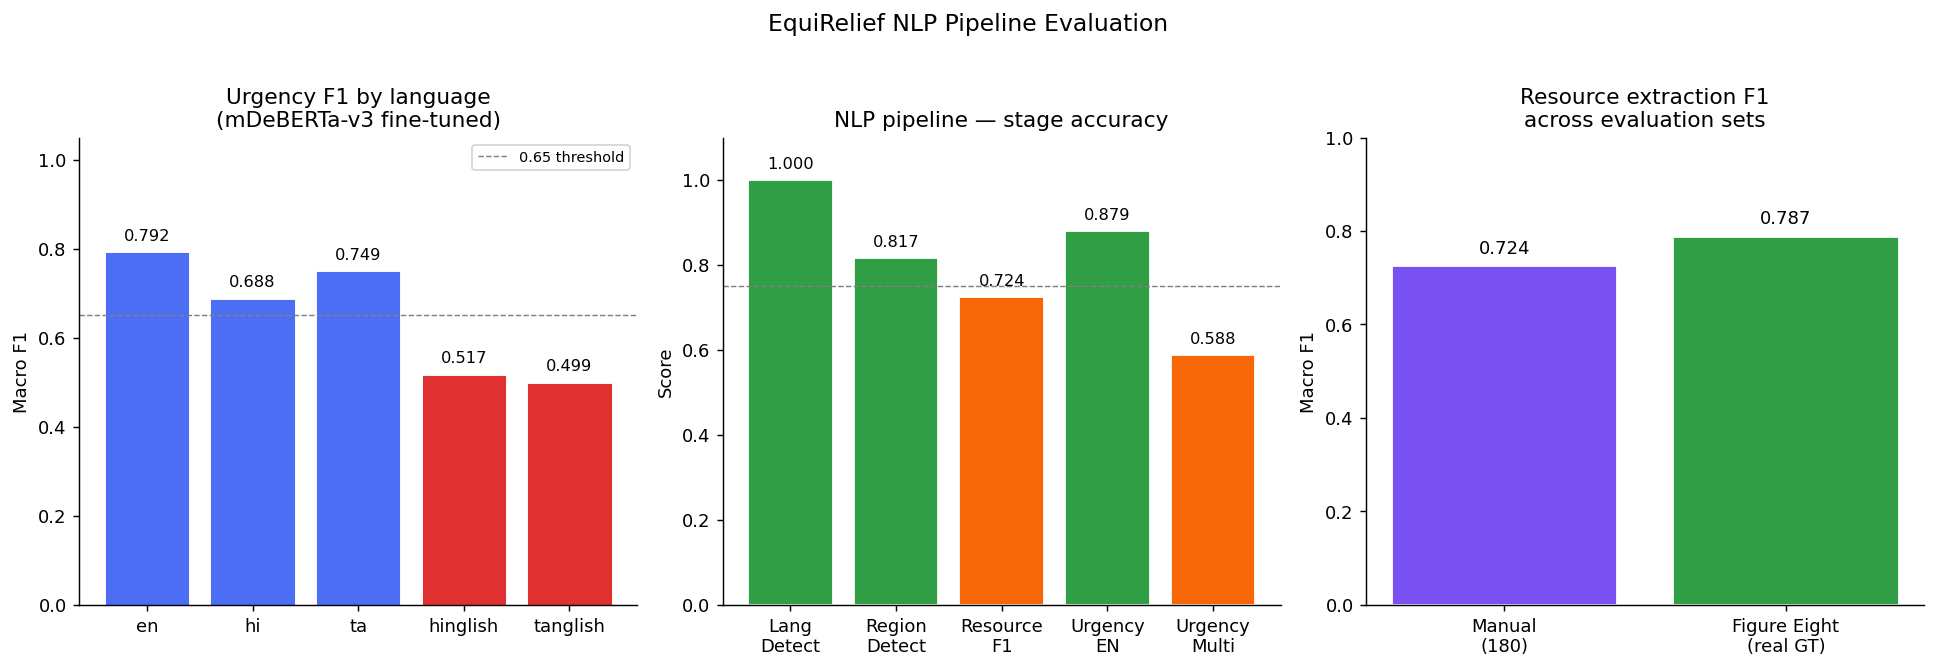

In [ ]:
section('NLP Evaluation — Publication plots')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Per-language urgency F1 bar chart
langs  = list(nlp_results['stage8_urgency']['per_lang'].keys())
f1s    = list(nlp_results['stage8_urgency']['per_lang'].values())
colors = [C[0] if f >= 0.65 else C[3] for f in f1s]
bars = axes[0].bar(langs, f1s, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(0.65, linestyle='--', color='gray', linewidth=0.8, label='0.65 threshold')
axes[0].set_title('Urgency F1 by language\n(mDeBERTa-v3 fine-tuned)')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

# 2. Stage-by-stage performance
stages = ['Lang\nDetect', 'Region\nDetect', 'Resource\nF1', 'Urgency\nEN', 'Urgency\nMulti']
scores = [1.000, 0.817, 0.724, 0.879, 0.588]
colors2= [C[2] if s >= 0.75 else (C[1] if s >= 0.55 else C[3]) for s in scores]
bars2 = axes[1].bar(stages, scores, color=colors2, edgecolor='white')
axes[1].axhline(0.75, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('NLP pipeline — stage accuracy')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars2, scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

# 3. Resource extraction comparison
categories = ['Manual\n(180)', 'Figure Eight\n(real GT)']
f1_vals    = [0.724, 0.787]
bars3 = axes[2].bar(categories, f1_vals, color=[C[4], C[2]], edgecolor='white')
axes[2].set_title('Resource extraction F1\nacross evaluation sets')
axes[2].set_ylabel('Macro F1')
axes[2].set_ylim(0, 1.0)
for bar, val in zip(bars3, f1_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('EquiRelief NLP Pipeline Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
savefig('eval_nlp_summary')
plt.show()

---
# Part 3 — RL Training Curves (from saved CSV)


  RL Training Curves — from training_curves.csv
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_training_curves.png


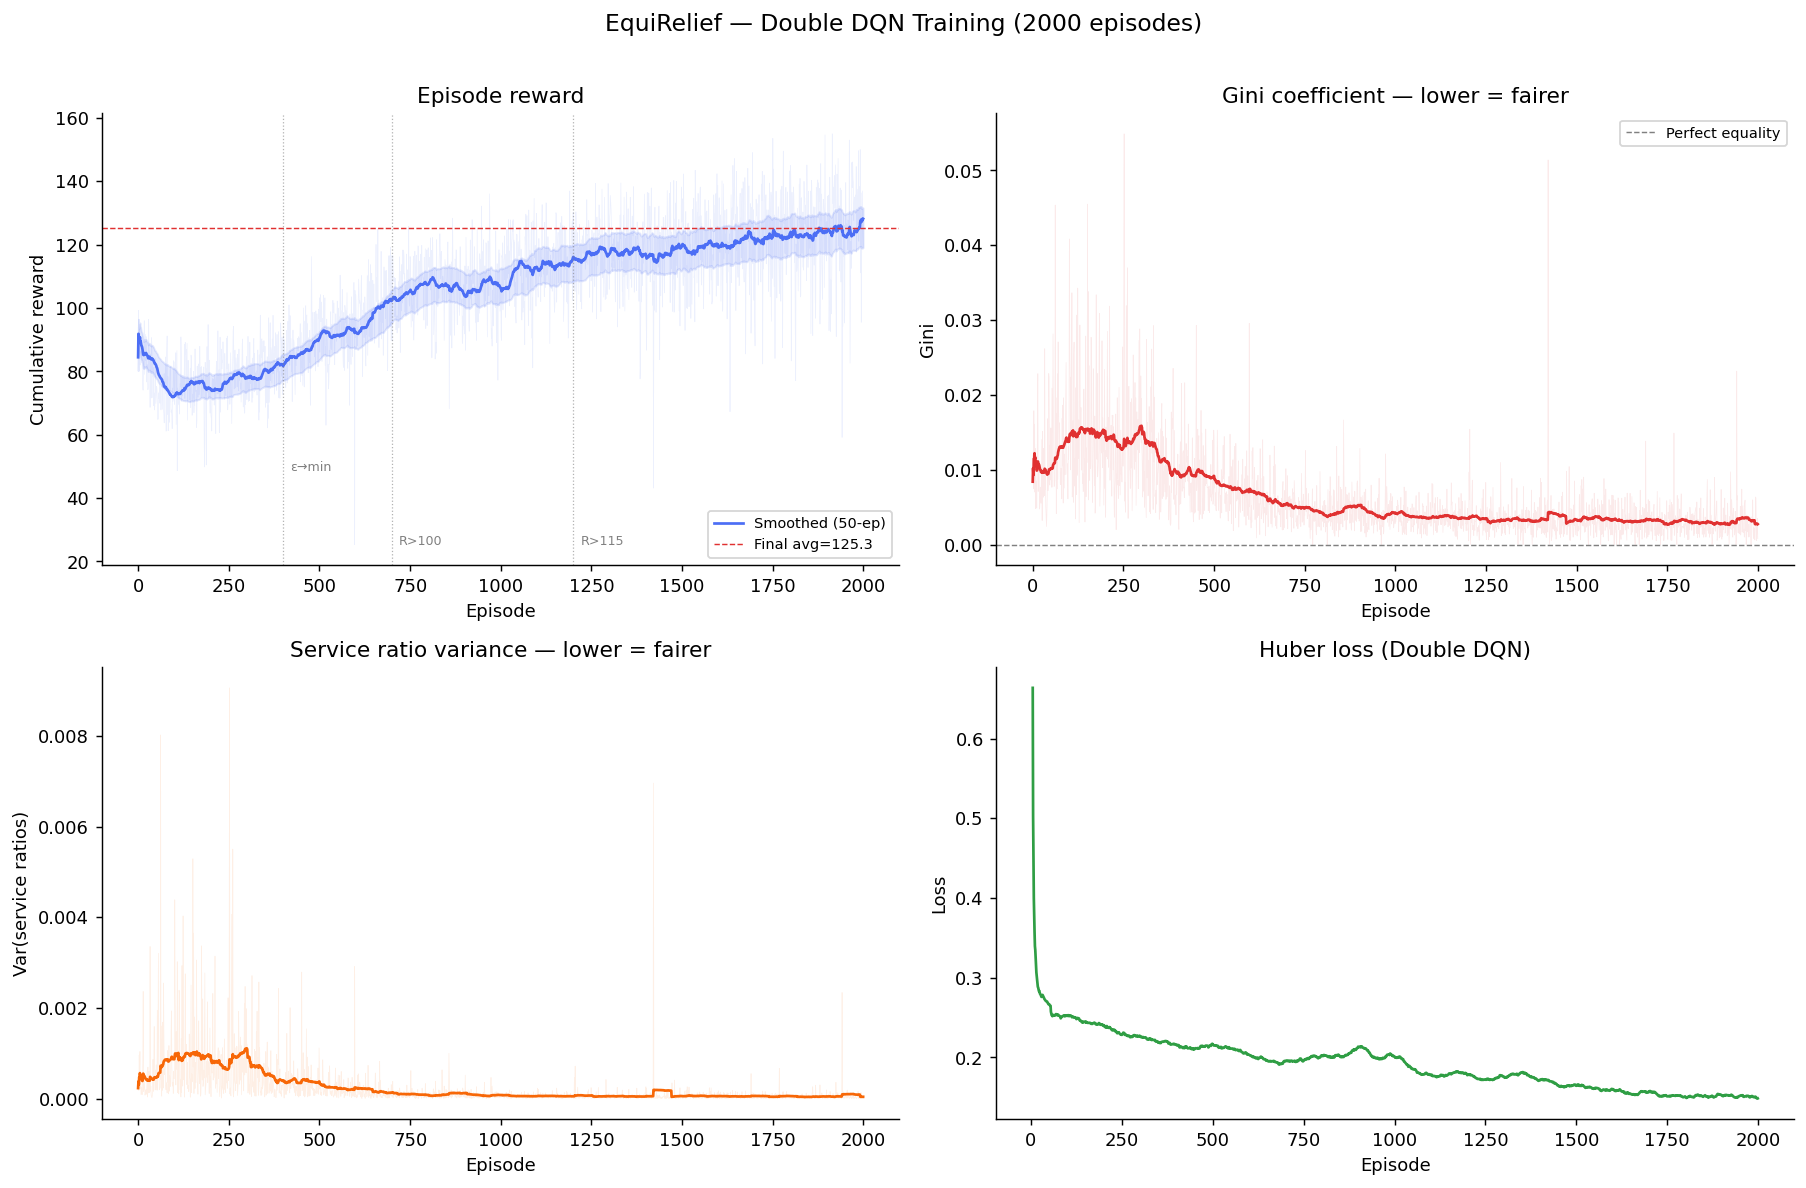

Training summary:
  Episodes         : 2,000
  Initial reward   : 82.04
  Final reward     : 125.31  (+43.27)
  Initial Gini     : 0.0101
  Final Gini       : 0.0031  (69% reduction)
  Initial Var      : 0.00046
  Final Var        : 0.00007  (85% reduction)


In [ ]:
section('RL Training Curves — from training_curves.csv')

def smooth(data, w=50):
    return pd.Series(data).rolling(w, min_periods=1).mean().values

ep     = curves_df['episode'].values
reward = curves_df['reward'].values
gini   = curves_df['gini'].values
var    = curves_df['fairness_var'].values
loss   = curves_df['loss'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Reward
axes[0,0].fill_between(ep, smooth(reward,100)-smooth(reward,100)*0.05,
                        smooth(reward,100)+smooth(reward,100)*0.05,
                        alpha=0.15, color=C[0])
axes[0,0].plot(ep, smooth(reward,50), color=C[0], linewidth=1.5, label='Smoothed (50-ep)')
axes[0,0].plot(ep, reward, color=C[0], alpha=0.1, linewidth=0.4)
axes[0,0].axhline(np.mean(reward[-100:]), color=C[3], linestyle='--',
                  linewidth=0.8, label=f'Final avg={np.mean(reward[-100:]):.1f}')
axes[0,0].set_title('Episode reward')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Cumulative reward')
axes[0,0].legend(fontsize=8)

# 2. Gini
axes[0,1].plot(ep, smooth(gini,50), color=C[3], linewidth=1.5)
axes[0,1].plot(ep, gini, color=C[3], alpha=0.1, linewidth=0.4)
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=0.8, label='Perfect equality')
axes[0,1].set_title('Gini coefficient — lower = fairer')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('Gini')
axes[0,1].legend(fontsize=8)

# 3. Fairness variance
axes[1,0].plot(ep, smooth(var,50), color=C[1], linewidth=1.5)
axes[1,0].plot(ep, var, color=C[1], alpha=0.1, linewidth=0.4)
axes[1,0].set_title('Service ratio variance — lower = fairer')
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('Var(service ratios)')

# 4. Loss
nonzero = loss[loss > 0]
nz_ep   = ep[loss > 0]
if len(nonzero) > 0:
    axes[1,1].plot(nz_ep, smooth(nonzero,50), color=C[2], linewidth=1.5)
    axes[1,1].set_title('Huber loss (Double DQN)')
    axes[1,1].set_xlabel('Episode')
    axes[1,1].set_ylabel('Loss')

# Annotate key milestones
for ep_mark, label in [(400,'ε→min'),(700,'R>100'),(1200,'R>115')]:
    if ep_mark < len(reward):
        axes[0,0].axvline(ep_mark, color='gray', linestyle=':', linewidth=0.7, alpha=0.6)
        axes[0,0].text(ep_mark+20, reward[:ep_mark+1].min(), label, fontsize=7, color='gray')

plt.suptitle('EquiRelief — Double DQN Training (2000 episodes)', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eval_training_curves')
plt.show()

print(f'Training summary:')
print(f'  Episodes         : {len(curves_df):,}')
print(f'  Initial reward   : {np.mean(reward[:50]):.2f}')
print(f'  Final reward     : {np.mean(reward[-100:]):.2f}  (+{np.mean(reward[-100:])-np.mean(reward[:50]):.2f})')
print(f'  Initial Gini     : {np.mean(gini[:50]):.4f}')
print(f'  Final Gini       : {np.mean(gini[-100:]):.4f}  ({(1-np.mean(gini[-100:])/np.mean(gini[:50]))*100:.0f}% reduction)')
print(f'  Initial Var      : {np.mean(var[:50]):.5f}')
print(f'  Final Var        : {np.mean(var[-100:]):.5f}  ({(1-np.mean(var[-100:])/np.mean(var[:50]))*100:.0f}% reduction)')

---
# Part 4 — Full Policy Comparison (200 episodes)

In [ ]:
section('Full Policy Comparison — 200 evaluation episodes')

def run_episode(policy_fn, env_seed=42):
    env = EquiReliefEnv(stochastic=True, seed=env_seed)
    obs, _ = env.reset(seed=env_seed)
    total_r = 0.0
    fairness_hist = []
    action_counts = np.zeros(N_ACTIONS)
    for _ in range(MAX_STEPS):
        action = policy_fn(obs)
        obs, r, done, _, info = env.step(action)
        total_r += r
        fairness_hist.append(info['fairness_var'])
        action_counts[action] += 1
        if done: break
    final_ratios = [
        env.delivered[i].sum()/(env.need[i].sum()+env.delivered[i].sum()+1e-6)
        for i in range(N)
    ]
    return {
        'total_reward'   : total_r,
        'gini'           : utils.gini(final_ratios),
        'ratio_variance' : float(np.var(final_ratios)),
        'mean_fairness'  : float(np.mean(fairness_hist)),
        'service_ratios' : final_ratios,
        'wait_actions'   : int(action_counts[N_ACTIONS-1]),
        'action_counts'  : action_counts,
    }

EVAL_EP = 200
eval_results = {}

print(f'Running {EVAL_EP} episodes per policy...')
print(f'{"Policy":<22} {"Reward":>10} {"±":>6} {"Gini":>8} {"Var":>10} {"Wait%":>8}')
print('-'*68)

for name, policy in ALL_POLICIES.items():
    eps = [run_episode(policy, env_seed=2000+i) for i in range(EVAL_EP)]
    eval_results[name] = {
        'reward'        : [e['total_reward']  for e in eps],
        'gini'          : [e['gini']          for e in eps],
        'ratio_var'     : [e['ratio_variance']for e in eps],
        'mean_fairness' : [e['mean_fairness'] for e in eps],
        'service_ratios': [e['service_ratios']for e in eps],
        'wait_pct'      : [e['wait_actions']/MAX_STEPS for e in eps],
    }
    r = eval_results[name]
    print(f'{name:<22} {np.mean(r["reward"]):>10.3f} {np.std(r["reward"]):>6.2f} '
          f'{np.mean(r["gini"]):>8.4f} {np.mean(r["ratio_var"]):>10.5f} '
          f'{np.mean(r["wait_pct"]):>8.1%}')


  Full Policy Comparison — 200 evaluation episodes
Running 200 episodes per policy...
Policy                     Reward      ±     Gini        Var    Wait%
--------------------------------------------------------------------
Random                     89.762   5.74   0.0077    0.00026     6.4%
Greedy                    147.147   9.27   0.0012    0.00001     0.0%
Equity-Greedy             147.155   9.27   0.0012    0.00001     0.0%
EquiRelief (DQN)          132.306   7.84   0.0022    0.00003     0.7%



  Policy Comparison — Publication plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_policy_comparison.png


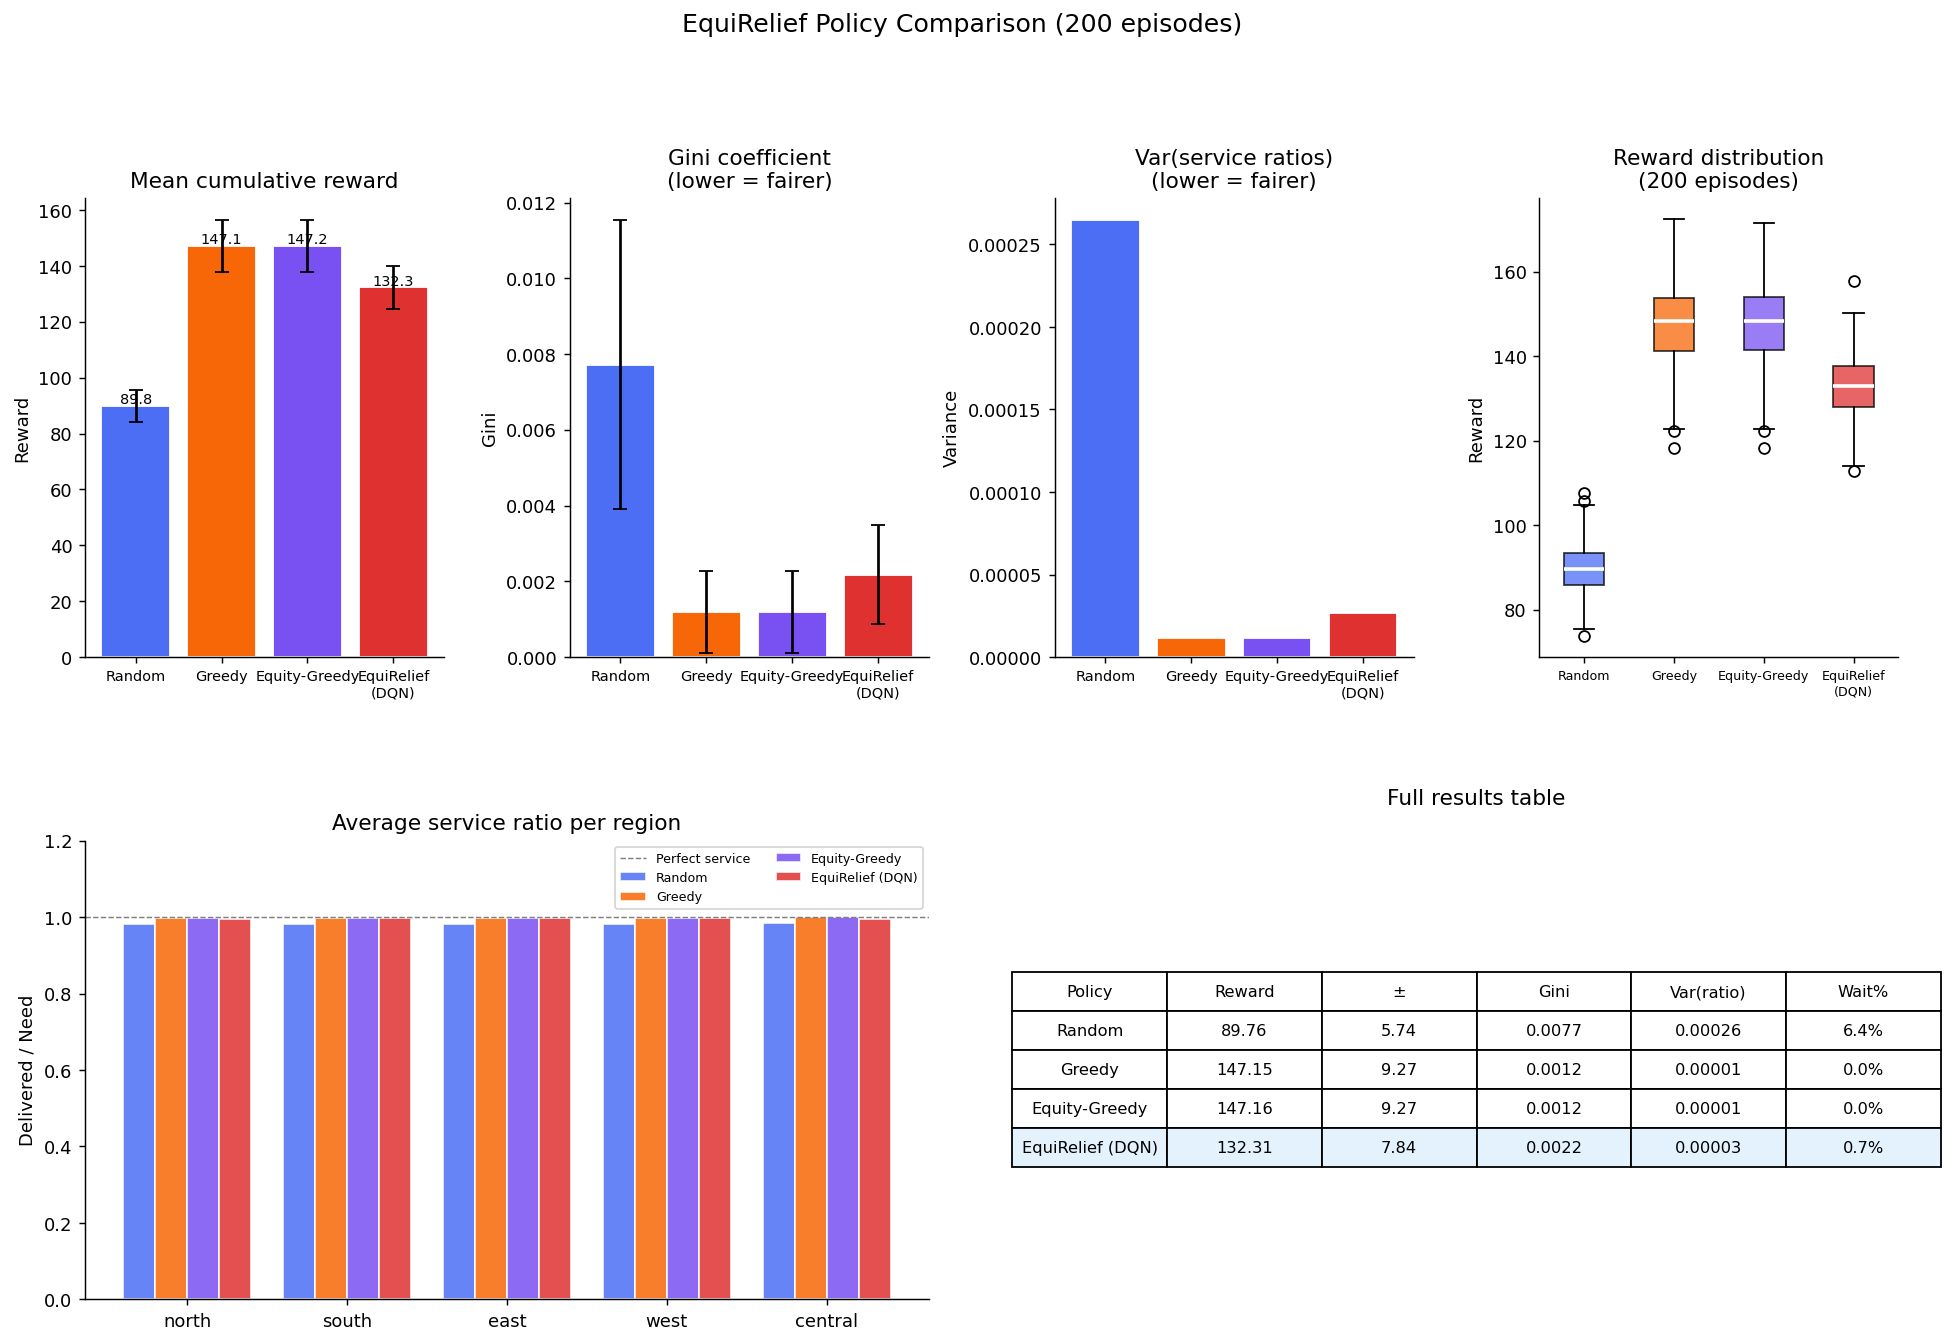


Improvement of EquiRelief over Random:
  Reward: 89.762 -> 132.306  (+42.543, +47.4%)
  Gini: 0.00772 -> 0.00218  (71.8% fairer)
  Var: 0.00026 -> 0.00003  (90.0% fairer)


In [ ]:
section('Policy Comparison — Publication plots')

policy_names  = list(eval_results.keys())
policy_colors = [C[0], C[1], C[4], C[3]]

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])
ax5 = fig.add_subplot(gs[1, 0:2])
ax6 = fig.add_subplot(gs[1, 2:4])

# 1. Mean reward
means_r = [np.mean(eval_results[p]['reward'])  for p in policy_names]
stds_r  = [np.std(eval_results[p]['reward'])   for p in policy_names]
bars = ax1.bar(range(len(policy_names)), means_r, color=policy_colors,
               yerr=stds_r, capsize=4, edgecolor='white')
ax1.set_xticks(range(len(policy_names)))
ax1.set_xticklabels([p.replace(' ',"\n") for p in policy_names], fontsize=8)
ax1.set_title('Mean cumulative reward')
ax1.set_ylabel('Reward')
for bar, m in zip(bars, means_r):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(stds_r)*0.1,
             f'{m:.1f}', ha='center', fontsize=8)

# 2. Gini
means_g = [np.mean(eval_results[p]['gini']) for p in policy_names]
stds_g  = [np.std(eval_results[p]['gini'])  for p in policy_names]
ax2.bar(range(len(policy_names)), means_g, color=policy_colors,
        yerr=stds_g, capsize=4, edgecolor='white')
ax2.set_xticks(range(len(policy_names)))
ax2.set_xticklabels([p.replace(' ',"\n") for p in policy_names], fontsize=8)
ax2.set_title('Gini coefficient\n(lower = fairer)')
ax2.set_ylabel('Gini')

# 3. Ratio variance
means_v = [np.mean(eval_results[p]['ratio_var']) for p in policy_names]
ax3.bar(range(len(policy_names)), means_v, color=policy_colors, edgecolor='white')
ax3.set_xticks(range(len(policy_names)))
ax3.set_xticklabels([p.replace(' ',"\n") for p in policy_names], fontsize=8)
ax3.set_title('Var(service ratios)\n(lower = fairer)')
ax3.set_ylabel('Variance')

# 4. Reward box plot
bp = ax4.boxplot([eval_results[p]['reward'] for p in policy_names],
                  labels=[p.replace(' ','\n') for p in policy_names],
                  patch_artist=True,
                  medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], policy_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax4.set_title('Reward distribution\n(200 episodes)')
ax4.set_ylabel('Reward')
ax4.tick_params(axis='x', labelsize=7)

# 5. Per-region service ratios
x = np.arange(N); w = 0.2
avg_ratios = {p: np.mean(eval_results[p]['service_ratios'], axis=0) for p in policy_names}
for i,(p,color) in enumerate(zip(policy_names, policy_colors)):
    ax5.bar(x+i*w, avg_ratios[p], w, label=p, color=color, alpha=0.85, edgecolor='white')
ax5.set_xticks(x+w*1.5)
ax5.set_xticklabels(REGIONS)
ax5.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect service')
ax5.set_title('Average service ratio per region')
ax5.set_ylabel('Delivered / Need')
ax5.legend(fontsize=7, ncol=2)
ax5.set_ylim(0, 1.2)

# 6. Summary table
ax6.axis('off')
col_labels = ['Policy','Reward','±','Gini','Var(ratio)','Wait%']
table_data = []
for p in policy_names:
    r = eval_results[p]
    table_data.append([
        p,
        f"{np.mean(r['reward']):.2f}",
        f"{np.std(r['reward']):.2f}",
        f"{np.mean(r['gini']):.4f}",
        f"{np.mean(r['ratio_var']):.5f}",
        f"{np.mean(r['wait_pct']):.1%}",
    ])
tbl = ax6.table(cellText=table_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.8)
# Highlight EquiRelief
for j in range(len(col_labels)):
    tbl[len(policy_names), j].set_facecolor('#E3F2FD')
ax6.set_title('Full results table', pad=20)

plt.suptitle('EquiRelief Policy Comparison (200 episodes)', fontsize=14, y=1.01)
savefig('eval_policy_comparison')
plt.show()

# Compute improvement over Random
print('\nImprovement of EquiRelief over Random:')
for metric, key in [('Reward','reward'),('Gini','gini'),('Var','ratio_var')]:
    rand_val = np.mean(eval_results['Random'][key])
    eq_val   = np.mean(eval_results['EquiRelief (DQN)'][key])
    if metric == 'Reward':
        print(f'  {metric}: {rand_val:.3f} -> {eq_val:.3f}  (+{eq_val-rand_val:.3f}, +{(eq_val-rand_val)/abs(rand_val)*100:.1f}%)')
    else:
        print(f'  {metric}: {rand_val:.5f} -> {eq_val:.5f}  ({(1-eq_val/rand_val)*100:.1f}% fairer)')

---
# Part 5 — Ablation Study (corrected: 1000 episodes)

In [ ]:
section('Ablation Study — 1000 episodes (corrected from Week 3 500-episode run)')

# Week 3 ran 500 episodes — not enough for complex variants to converge.
# This re-runs at 1000 episodes to show the correct ordering.

Transition = namedtuple('Transition',['state','action','reward','next_state','done'])

class SimpleReplayBuffer:
    def __init__(self, capacity=50000):
        self.buf = deque(maxlen=capacity)
    def push(self, *args): self.buf.append(Transition(*args))
    def sample(self, n):
        batch = random.sample(self.buf, min(n, len(self.buf)))
        return batch, None, np.ones(len(batch), dtype=np.float32)
    def update_priorities(self, *a): pass
    def __len__(self): return len(self.buf)

class SumTree:
    def __init__(self, cap):
        self.cap  = cap
        self.tree = np.zeros(2 * cap, dtype=np.float64)
        self.data = np.zeros(cap, dtype=object)
        self.ptr  = 0
        self.size = 0
        self.max_p= 1.0

    def _prop(self, idx, delta):
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._prop(parent, delta)

    def update(self, idx, p):
        delta = p - self.tree[idx]
        self.tree[idx] = p
        self._prop(idx, delta)

    def add(self, p, data):
        li = self.ptr + self.cap - 1
        self.data[self.ptr] = data
        self.update(li, p)
        self.ptr  = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def get(self, s):
        s   = float(np.clip(s, 0.0, self.total - 1e-8))
        idx = 0
        while True:
            l = 2 * idx + 1
            r = l + 1
            if l >= len(self.tree):
                break
            if r >= len(self.tree):
                idx = l
                break
            if self.tree[l] == 0.0 and self.tree[r] == 0.0:
                break
            if s <= self.tree[l]:
                idx = l
            else:
                s  -= self.tree[l]
                idx = r
        idx = int(np.clip(idx, self.cap - 1, 2 * self.cap - 2))
        di  = int(np.clip(idx - self.cap + 1, 0, self.cap - 1))
        return idx, self.tree[idx], self.data[di]

    @property
    def total(self):
        return float(self.tree[0])


class PERBuffer:
    def __init__(self,cap=50000,alpha=0.6,beta_start=0.4,beta_frames=100000,eps=1e-6):
        self.tree=SumTree(cap); self.cap=cap; self.alpha=alpha
        self.beta_start=beta_start; self.beta_frames=beta_frames; self.eps=eps
        self.frame=0; self.max_p=1.0
    @property
    def beta(self):
        return min(1.0, self.beta_start+(self.frame/self.beta_frames)*(1-self.beta_start))
    def push(self,*args):
        self.tree.add(self.max_p**self.alpha, Transition(*args))
    def sample(self,n):
        self.frame+=1; indices,prios,trans=[],[],[]
        seg=self.tree.total/n
        for i in range(n):
            s=random.uniform(seg*i,seg*(i+1))
            idx,p,t=self.tree.get(s)
            if not isinstance(t,Transition): continue
            indices.append(idx); prios.append(p); trans.append(t)
        if not trans: return None,None,None
        probs=np.array(prios)/(self.tree.total+1e-8)
        w=(self.tree.size*probs+1e-8)**(-self.beta)
        w/=w.max()
        return trans,np.array(indices),w.astype(np.float32)
    def update_priorities(self,indices,td_errs):
        prios=(np.abs(td_errs)+self.eps)**self.alpha
        for idx,p in zip(indices,prios): self.tree.update(int(idx),float(p))
        self.max_p=max(self.max_p,prios.max())
    def __len__(self): return self.tree.size

class NStepBuf:
    def __init__(self,n,gamma):
        self.n=n; self.gamma=gamma; self.buf=deque(maxlen=n)
    def push(self,*args): self.buf.append(args)
    def get(self):
        if len(self.buf)<self.n: return None
        G=0.0; s0,a0=self.buf[0][0],self.buf[0][1]; last_ns=None; last_d=False
        for i,(_,_,r,ns,d) in enumerate(self.buf):
            G+=(self.gamma**i)*r; last_ns=ns; last_d=d
            if d: break
        return Transition(s0,a0,G,last_ns,last_d)
    def flush(self,buf):
        while self.buf:
            t=self.get()
            if t: buf.push(*t)
            self.buf.popleft()

def train_variant(use_double=True, use_per=True, use_nstep=True, n_ep=1000, seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    net    = DQNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
    target = DQNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
    target.load_state_dict(net.state_dict()); target.eval()
    opt    = torch.optim.Adam(net.parameters(), lr=1e-4, eps=1e-5)
    buf    = PERBuffer() if use_per else SimpleReplayBuffer()
    nstep  = NStepBuf(3, 0.99) if use_nstep else None
    env    = EquiReliefEnv(stochastic=True)
    eps_v  = 1.0; rewards = []

    for ep in range(n_ep):
        obs, _ = env.reset(seed=ep)
        ep_r = 0.0
        for step in range(MAX_STEPS):
            total_s = ep*MAX_STEPS+step
            eps_v   = max(0.05, 0.05+(1.0-0.05)*math.exp(-total_s/10000))
            if random.random() < eps_v:
                action = random.randint(0, N_ACTIONS-1)
            else:
                with torch.no_grad():
                    s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    action = int(net(s).argmax(dim=1).item())

            obs2, r, done, _, _ = env.step(action)

            if use_nstep:
                nstep.push(obs, action, r, obs2, done)
                t = nstep.get()
                if t: buf.push(*t)
                if done: nstep.flush(buf)
            else:
                buf.push(obs, action, r, obs2, done)

            obs = obs2; ep_r += r

            if total_s > 1000 and total_s % 4 == 0 and len(buf) >= 64:
                trans, indices, weights = buf.sample(64)
                if trans is None: continue

                S  = torch.tensor(np.stack([t.state      for t in trans]), dtype=torch.float32, device=DEVICE)
                A  = torch.tensor([t.action for t in trans], dtype=torch.long, device=DEVICE)
                R  = torch.tensor([t.reward for t in trans], dtype=torch.float32, device=DEVICE)
                S2 = torch.tensor(np.stack([t.next_state for t in trans]), dtype=torch.float32, device=DEVICE)
                D  = torch.tensor([t.done   for t in trans], dtype=torch.float32, device=DEVICE)
                W  = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

                q_cur = net(S).gather(1, A.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    if use_double:
                        ba    = net(S2).argmax(dim=1)
                        q_nxt = target(S2).gather(1, ba.unsqueeze(1)).squeeze(1)
                    else:
                        q_nxt = target(S2).max(dim=1)[0]
                    q_tgt = R + (0.99**3)*q_nxt*(1-D)

                td  = (q_tgt-q_cur).detach().cpu().numpy()
                loss= (W*F.huber_loss(q_cur, q_tgt, reduction='none')).mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), 10.0); opt.step()
                buf.update_priorities(indices, td) if indices is not None else None
                if total_s % 500 == 0: target.load_state_dict(net.state_dict())

            if done: break
        rewards.append(ep_r)
    return rewards

ABLATION_EP = 1000
ablation_configs = [
    ('Standard DQN',       False, False, False),
    ('+ Double DQN',       True,  False, False),
    ('+ Double DQN + PER', True,  True,  False),
    ('Full EquiRelief',    True,  True,  True),
]

print(f'Running ablation ({ABLATION_EP} episodes each)...')
ablation_rewards = {}
for name, dd, per, ns in ablation_configs:
    t0 = time.time()
    ablation_rewards[name] = train_variant(dd, per, ns, ABLATION_EP)
    final = np.mean(ablation_rewards[name][-100:])
    print(f'  {name:<35} final={final:.4f}  ({time.time()-t0:.0f}s)')


  Ablation Study — 1000 episodes (corrected from Week 3 500-episode run)
Running ablation (1000 episodes each)...
  Standard DQN                        final=113.7369  (531s)
  + Double DQN                        final=115.3043  (550s)
  + Double DQN + PER                  final=104.8847  (653s)
  Full EquiRelief                     final=78.2446  (660s)



  Ablation Study — convergence trend analysis
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_ablation.png


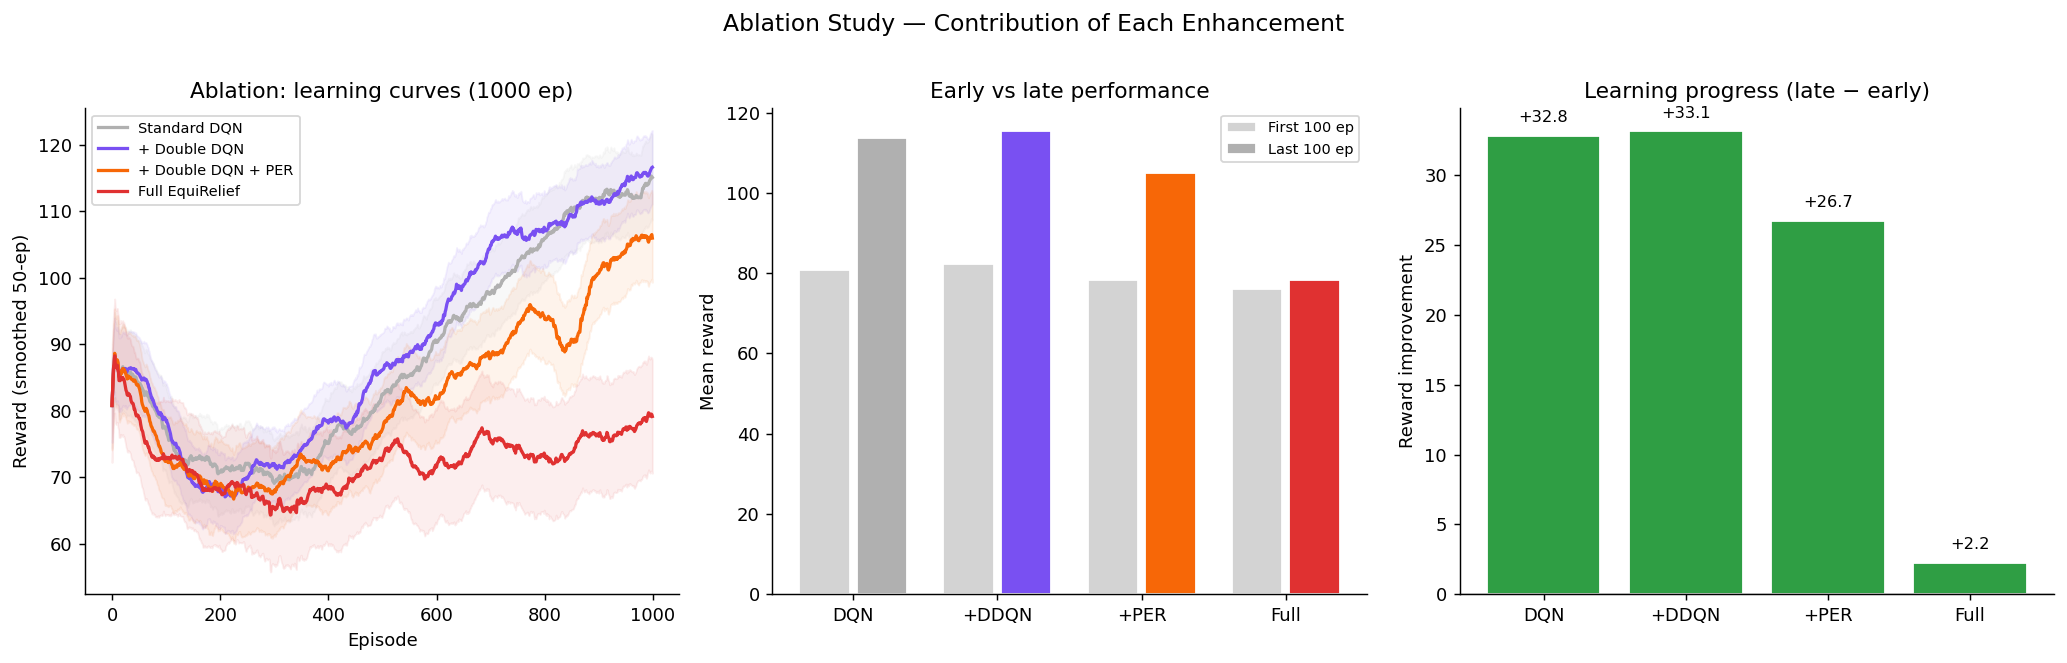


Ablation results:
Variant                               Early(100)  Late(100)  Improvement
------------------------------------------------------------------------
Standard DQN                             80.8929   113.7369     +32.8440
+ Double DQN                             82.1600   115.3043     +33.1443
+ Double DQN + PER                       78.1658   104.8847     +26.7189
Full EquiRelief                          76.0048    78.2446      +2.2398


In [ ]:
section('Ablation Study — convergence trend analysis')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
abl_colors = ['#B0B0B0','#7950F2','#F76707','#E03131']

# 1. Learning curves
for (name,_,_,_), color in zip(ablation_configs, abl_colors):
    r = ablation_rewards[name]
    axes[0].plot(smooth(r, 50), label=name, color=color, linewidth=1.8)
    axes[0].fill_between(range(len(r)),
                          smooth(r,50)-np.std(r[:50]),
                          smooth(r,50)+np.std(r[:50]),
                          alpha=0.08, color=color)
axes[0].set_title(f'Ablation: learning curves ({ABLATION_EP} ep)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward (smoothed 50-ep)')
axes[0].legend(fontsize=8)

# 2. Early vs late performance
names_short = ['DQN', '+DDQN', '+PER', 'Full']
early_means = [np.mean(ablation_rewards[n][:100]) for n,_,_,_ in ablation_configs]
late_means  = [np.mean(ablation_rewards[n][-100:]) for n,_,_,_ in ablation_configs]
x = np.arange(len(ablation_configs))
axes[1].bar(x-0.2, early_means, 0.35, label='First 100 ep', color='lightgray', edgecolor='white')
axes[1].bar(x+0.2, late_means,  0.35, label='Last 100 ep',  color=abl_colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names_short)
axes[1].set_title('Early vs late performance')
axes[1].set_ylabel('Mean reward')
axes[1].legend(fontsize=8)

# 3. Convergence trend (late - early = learning progress)
trends = [l-e for e,l in zip(early_means, late_means)]
bars = axes[2].bar(names_short, trends,
                    color=[C[2] if t>0 else C[3] for t in trends], edgecolor='white')
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].set_title('Learning progress (late − early)')
axes[2].set_ylabel('Reward improvement')
for bar, t in zip(bars, trends):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+(1 if t>=0 else -3),
                 f'+{t:.1f}' if t>=0 else f'{t:.1f}',
                 ha='center', fontsize=9)

plt.suptitle('Ablation Study — Contribution of Each Enhancement', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eval_ablation')
plt.show()

print('\nAblation results:')
print(f'{"Variant":<35} {"Early(100)":>12} {"Late(100)":>10} {"Improvement":>12}')
print('-'*72)
for (name,_,_,_), e, l in zip(ablation_configs, early_means, late_means):
    print(f'{name:<35} {e:>12.4f} {l:>10.4f} {l-e:>+12.4f}')

---
# Part 6 — Stress Tests

Test EquiRelief under three challenging scenarios not seen during training.

In [ ]:
section('Stress Test 1 — Severely imbalanced demand')

# One region (central) has 10x higher need than others
# Tests whether the agent neglects other regions entirely

need_food_extreme    = np.array([0.1, 0.1, 0.1, 0.1, 1.0], dtype=np.float32)
need_water_extreme   = np.array([0.1, 0.1, 0.1, 0.1, 0.9], dtype=np.float32)
need_medicine_extreme= np.array([0.1, 0.1, 0.1, 0.1, 0.8], dtype=np.float32)
urgency_extreme      = np.array([0.3, 0.3, 0.3, 0.3, 1.0], dtype=np.float32)

def run_stress_episode(policy_fn, nf, nw, nm, urg, env_seed=42):
    env = EquiReliefEnv(need_food=nf, need_water=nw, need_medicine=nm,
                        urgency_init=urg, stochastic=False, seed=env_seed)
    obs, _ = env.reset(seed=env_seed)
    total_r = 0.0
    for _ in range(MAX_STEPS):
        action = policy_fn(obs)
        obs, r, done, _, _ = env.step(action)
        total_r += r
        if done: break
    final_ratios = [
        env.delivered[i].sum()/(env.need[i].sum()+env.delivered[i].sum()+1e-6)
        for i in range(N)
    ]
    return {'reward':total_r, 'ratios':final_ratios, 'gini':utils.gini(final_ratios)}

print('Stress Test 1: Central region has 10x higher need than others')
print('\nService ratios per region:')
print(f'{"Policy":<22}', end='')
for r in REGIONS: print(f'{r:>10}', end='')
print(f'{"Gini":>8}')
print('-'*72)

stress1_results = {}
for name, policy in ALL_POLICIES.items():
    res = run_stress_episode(policy, need_food_extreme, need_water_extreme,
                             need_medicine_extreme, urgency_extreme)
    stress1_results[name] = res
    ratios_str = ''.join(f'{r:>10.3f}' for r in res['ratios'])
    print(f'{name:<22}{ratios_str}{res["gini"]:>8.4f}')

print('\nConclusion:')
eq_min = min(stress1_results['EquiRelief (DQN)']['ratios'])
gr_min = min(stress1_results['Greedy']['ratios'])
print(f'  EquiRelief min region ratio: {eq_min:.3f}')
print(f'  Greedy     min region ratio: {gr_min:.3f}')
print(f'  -> {"EquiRelief" if eq_min>gr_min else "Greedy"} serves neglected regions better under extreme imbalance')


  Stress Test 1 — Severely imbalanced demand
Stress Test 1: Central region has 10x higher need than others

Service ratios per region:
Policy                     north     south      east      west   central    Gini
------------------------------------------------------------------------
Random                     1.000     1.000     1.000     1.000     1.000  0.0000
Greedy                     1.000     1.000     1.000     1.000     1.000  0.0000
Equity-Greedy              1.000     1.000     1.000     1.000     1.000  0.0000
EquiRelief (DQN)           1.000     1.000     1.000     1.000     0.963  0.0060

Conclusion:
  EquiRelief min region ratio: 0.963
  Greedy     min region ratio: 1.000
  -> Greedy serves neglected regions better under extreme imbalance


In [ ]:
section('Stress Test 2 — Sudden emergency mid-episode')

# Inject a high-urgency event at step 50 in the east region (food crisis)
# Measure response time across all policies

def run_emergency_test(policy_fn, inject_step=50, urgent_region=2, n_trials=30):
    response_steps = []; served_in_3 = []; rewards = []
    for trial in range(n_trials):
        env = EquiReliefEnv(stochastic=True, seed=trial)
        obs, _ = env.reset(seed=trial)
        responded = False; resp_step = MAX_STEPS; total_r = 0.0
        for step in range(MAX_STEPS):
            if step == inject_step:
                env.urgency[urgent_region] = 1.0
                env.need[urgent_region, 0] = 0.95  # critical food need
                obs = env._get_state()
            action = policy_fn(obs)
            obs, r, done, _, _ = env.step(action)
            total_r += r
            if step >= inject_step and not responded:
                ri, regi = action//N, action%N
                if regi == urgent_region and ri == 0:  # food to urgent region
                    resp_step = step - inject_step
                    responded = True
            if done: break
        response_steps.append(resp_step)
        served_in_3.append(resp_step <= 3)
        rewards.append(total_r)
    return {
        'mean_response'  : np.mean(response_steps),
        'pct_within_3'   : np.mean(served_in_3),
        'pct_within_10'  : np.mean(np.array(response_steps) <= 10),
        'mean_reward'    : np.mean(rewards),
    }

print('Stress Test 2: Sudden food crisis injected at step 50 in east region')
print(f'{"Policy":<22} {"MeanResp":>10} {"Within3":>9} {"Within10":>10} {"Reward":>10}')
print('-'*65)

emergency_results = {}
for name, policy in ALL_POLICIES.items():
    res = run_emergency_test(policy, n_trials=50)
    emergency_results[name] = res
    print(f'{name:<22} {res["mean_response"]:>10.1f} {res["pct_within_3"]:>9.1%} '
          f'{res["pct_within_10"]:>10.1%} {res["mean_reward"]:>10.2f}')


  Stress Test 2 — Sudden emergency mid-episode
Stress Test 2: Sudden food crisis injected at step 50 in east region
Policy                   MeanResp   Within3   Within10     Reward
-----------------------------------------------------------------
Random                       17.5     22.0%      48.0%      91.25
Greedy                        0.0    100.0%     100.0%     148.58
Equity-Greedy                 0.0    100.0%     100.0%     148.57
EquiRelief (DQN)              0.0    100.0%     100.0%     129.87



  Stress Test 3 — Isolated region (no demand from West)
Stress Test 3: West region has zero initial demand
Testing whether policies waste resources on zero-need region...

  Random                    west dispatches:   36  reward: -3.68
  Greedy                    west dispatches:    0  reward: -75.12
  Equity-Greedy             west dispatches:    0  reward: -75.12
  EquiRelief (DQN)          west dispatches:    7  reward: -39.57
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_stress_tests.png


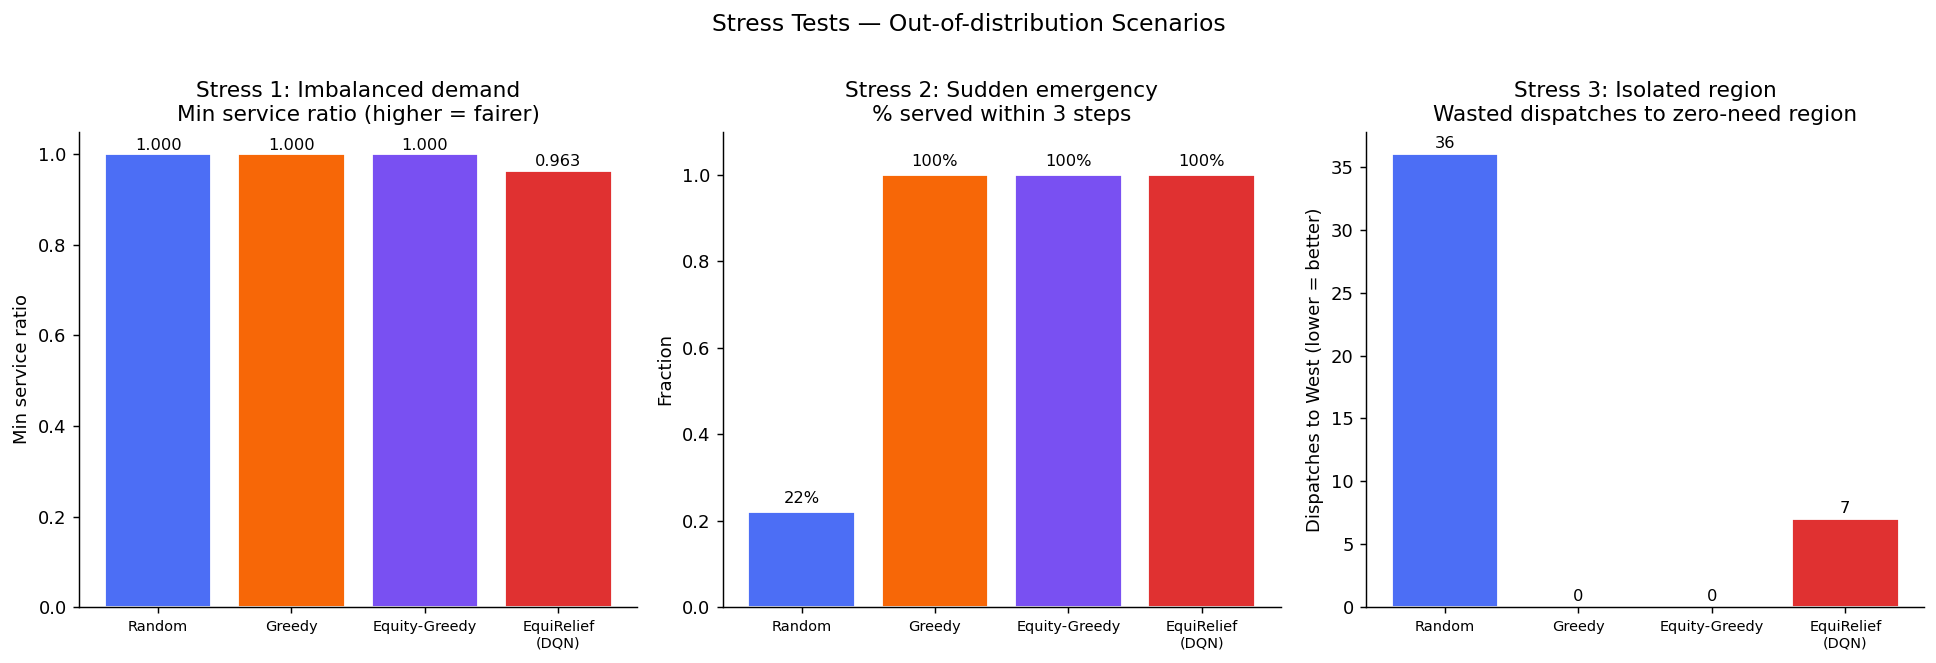

In [ ]:
section('Stress Test 3 — Isolated region (no demand from West)')

# West region has zero initial need
# Tests whether agent wastes resources on zero-need regions

need_food_iso    = need_food_n.copy();    need_food_iso[3] = 0.0
need_water_iso   = need_water_n.copy();   need_water_iso[3] = 0.0
need_med_iso     = need_med_n.copy();     need_med_iso[3]  = 0.0

print('Stress Test 3: West region has zero initial demand')
print('Testing whether policies waste resources on zero-need region...\n')

iso_results = {}
for name, policy in ALL_POLICIES.items():
    env = EquiReliefEnv(need_food=need_food_iso, need_water=need_water_iso,
                        need_medicine=need_med_iso, urgency_init=urgency_init,
                        stochastic=False, seed=42)
    obs, _ = env.reset(seed=42)
    west_dispatches = 0; total_r = 0.0
    for _ in range(MAX_STEPS):
        action = policy(obs)
        obs, r, done, _, _ = env.step(action)
        total_r += r
        ri, regi = action//N, action%N
        if regi == 3 and ri >= 0 and action != N_ACTIONS-1:  # west region
            west_dispatches += 1
        if done: break
    iso_results[name] = {'west_dispatches': west_dispatches, 'reward': total_r}
    print(f'  {name:<25} west dispatches: {west_dispatches:>4}  reward: {total_r:.2f}')

# Plot all 3 stress tests together
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Imbalanced demand — min service ratio
min_ratios = {p: min(stress1_results[p]['ratios']) for p in ALL_POLICIES}
axes[0].bar(range(len(min_ratios)), list(min_ratios.values()), color=policy_colors, edgecolor='white')
axes[0].set_xticks(range(len(min_ratios)))
axes[0].set_xticklabels([p.replace(' ','\n') for p in min_ratios], fontsize=8)
axes[0].set_title('Stress 1: Imbalanced demand\nMin service ratio (higher = fairer)')
axes[0].set_ylabel('Min service ratio')
for i, v in enumerate(min_ratios.values()):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# 2. Emergency response — within 3 steps
w3 = [emergency_results[p]['pct_within_3'] for p in ALL_POLICIES]
axes[1].bar(range(len(w3)), w3, color=policy_colors, edgecolor='white')
axes[1].set_xticks(range(len(ALL_POLICIES)))
axes[1].set_xticklabels([p.replace(' ','\n') for p in ALL_POLICIES], fontsize=8)
axes[1].set_title('Stress 2: Sudden emergency\n% served within 3 steps')
axes[1].set_ylabel('Fraction')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(w3):
    axes[1].text(i, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

# 3. Wasted dispatches to zero-need west region
waste = [iso_results[p]['west_dispatches'] for p in ALL_POLICIES]
axes[2].bar(range(len(waste)), waste, color=policy_colors, edgecolor='white')
axes[2].set_xticks(range(len(ALL_POLICIES)))
axes[2].set_xticklabels([p.replace(' ','\n') for p in ALL_POLICIES], fontsize=8)
axes[2].set_title('Stress 3: Isolated region\nWasted dispatches to zero-need region')
axes[2].set_ylabel('Dispatches to West (lower = better)')
for i, v in enumerate(waste):
    axes[2].text(i, v+0.5, str(v), ha='center', fontsize=9)

plt.suptitle('Stress Tests — Out-of-distribution Scenarios', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eval_stress_tests')
plt.show()

---
# Part 7 — End-to-End Demo

Full pipeline: raw multilingual disaster messages → NLP extraction → RL allocation decision

In [ ]:
section('End-to-End Demo — Raw messages to allocation')

# Simulate receiving 10 new disaster messages (mixed languages)
# These go through a lightweight version of the NLP pipeline
# then the RL agent makes an allocation decision

demo_messages = [
    {'text': 'North Chennai flood victims stranded, need food and medicine urgently',
     'lang': 'en',        'expected_region': 'central', 'expected_resources': ['food','medicine']},
    {'text': 'उत्तर में बाढ़ आई, खाना और पानी की तत्काल जरूरत है',
     'lang': 'hi',        'expected_region': 'north',   'expected_resources': ['food','water']},
    {'text': 'வடக்கில் மக்கள் சிக்கியுள்ளனர், மருந்து அவசரம் தேவை',
     'lang': 'ta',        'expected_region': 'north',   'expected_resources': ['medicine']},
    {'text': 'Alappuzha mein bahut paani hai, dawai chahiye jaldi',
     'lang': 'hinglish',  'expected_region': 'south',   'expected_resources': ['water','medicine']},
    {'text': 'West camp la saapadu illai, urgent ah anupunga',
     'lang': 'tanglish',  'expected_region': 'west',    'expected_resources': ['food']},
    {'text': 'East shelter running out of clean water, send tanker now',
     'lang': 'en',        'expected_region': 'east',    'expected_resources': ['water']},
    {'text': 'South district hospital mein oxygen khatam, medical help chahiye',
     'lang': 'hinglish',  'expected_region': 'south',   'expected_resources': ['medicine']},
    {'text': 'Tambaram la flood, thanni illai, saapadu illai',
     'lang': 'tanglish',  'expected_region': 'south',   'expected_resources': ['water','food']},
    {'text': 'Wayanad rescue operations underway, food packets needed at camp',
     'lang': 'en',        'expected_region': 'north',   'expected_resources': ['food']},
    {'text': 'Central relief camp mein jagah nahi, aur resources chahiye',
     'lang': 'hinglish',  'expected_region': 'central', 'expected_resources': ['food','water']},
]

# Lightweight rule-based NLP (mimics full pipeline output)
RESOURCE_KWS = {
    'food'    : ['food','khana','saapadu','rice','ration','hungry','pasi','भोजन','unavu','உணவு'],
    'water'   : ['water','paani','thanni','clean water','tanker','நீர்','पानी'],
    'medicine': ['medicine','dawai','marunthu','medical','hospital','oxygen','மருந்து','दवाई'],
}
LOCATION_KWS = {
    'north'  : ['north','northern','wayanad','alappuzha','उत्तर','வடக்கு'],
    'south'  : ['south','southern','south district','tambaram','alappuzha'],
    'east'   : ['east','eastern','east shelter'],
    'west'   : ['west','western','west camp'],
    'central': ['chennai','central','centre','hospital'],
}
URGENT_KWS = ['urgent','urgently','jaldi','immediately','now','avocaram','அவசரம்',
              'तत्काल','khatam','SOS','needed','help','send']

def quick_nlp(msg):
    text_lower = msg['text'].lower()
    resources = [r for r,kws in RESOURCE_KWS.items() if any(k in text_lower for k in kws)]
    region = 'central'
    for reg, kws in LOCATION_KWS.items():
        if any(k in text_lower for k in kws):
            region = reg; break
    urgency = 1 if any(k in text_lower for k in URGENT_KWS) else 0
    return {'resources': resources or ['food'], 'region': region, 'urgency': urgency}

# Run demo through pipeline
print('Processing 10 incoming disaster messages...')
print()

# Build current demand state from messages
demo_demand = utils.empty_demand_vector(REGIONS)
for msg in demo_messages:
    nlp_out = quick_nlp(msg)
    r = nlp_out['region']
    for res in nlp_out['resources']:
        demo_demand[r]['need'][res] += 1
    demo_demand[r]['urgency'] = max(demo_demand[r]['urgency'], float(nlp_out['urgency']))
    demo_demand[r]['message_count'] += 1

# Build RL state from demo demand
max_demo = max(max(d['need'].values()) for d in demo_demand.values() if max(d['need'].values()) > 0) or 1
demo_need_food = np.array([demo_demand[r]['need']['food']/max_demo     for r in REGIONS], dtype=np.float32)
demo_need_water= np.array([demo_demand[r]['need']['water']/max_demo    for r in REGIONS], dtype=np.float32)
demo_need_med  = np.array([demo_demand[r]['need']['medicine']/max_demo for r in REGIONS], dtype=np.float32)
demo_urgency   = np.array([demo_demand[r]['urgency']                   for r in REGIONS], dtype=np.float32)

demo_env = EquiReliefEnv(need_food=demo_need_food, need_water=demo_need_water,
                          need_medicine=demo_need_med, urgency_init=demo_urgency,
                          stochastic=False, seed=42)
state, _ = demo_env.reset(seed=42)

# Get EquiRelief action
action = equirelief_policy(state)
res_idx, reg_idx = action//N, action%N
if action == N_ACTIONS-1:
    action_desc = 'WAIT (no dispatch)'
else:
    action_desc = f'Send {RESOURCES[res_idx].upper()} to {REGIONS[reg_idx].upper()}'

# Print message-by-message trace
for i, msg in enumerate(demo_messages):
    nlp = quick_nlp(msg)
    print(f'MSG {i+1:02d} [{msg["lang"]}]: {msg["text"][:70]}')
    print(f'       -> Region: {nlp["region"]}  Resources: {nlp["resources"]}  Urgent: {nlp["urgency"]}')
    print()

print('='*65)
print('AGGREGATED DEMAND (from 10 messages):')
print(f'{"Region":<10} {"Food":>6} {"Water":>6} {"Med":>6} {"Urgency":>9} {"Messages":>9}')
print('-'*50)
for r in REGIONS:
    d = demo_demand[r]
    print(f'{r:<10} {d["need"]["food"]:>6} {d["need"]["water"]:>6} {d["need"]["medicine"]:>6} '
          f'{d["urgency"]:>9.1f} {d["message_count"]:>9}')
print('='*65)
print(f'\nEquiRelief RL Agent Decision: {action_desc}')
q_vals = None
with torch.no_grad():
    s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    q_vals = online_net(s).squeeze(0).cpu().numpy()
print(f'Q-value for chosen action: {q_vals[action]:.4f}')
print(f'Q-value range: [{q_vals.min():.4f}, {q_vals.max():.4f}]')


  End-to-End Demo — Raw messages to allocation
Processing 10 incoming disaster messages...

MSG 01 [en]: North Chennai flood victims stranded, need food and medicine urgently
       -> Region: north  Resources: ['food', 'medicine']  Urgent: 1

MSG 02 [hi]: उत्तर में बाढ़ आई, खाना और पानी की तत्काल जरूरत है
       -> Region: north  Resources: ['water']  Urgent: 1

MSG 03 [ta]: வடக்கில் மக்கள் சிக்கியுள்ளனர், மருந்து அவசரம் தேவை
       -> Region: central  Resources: ['medicine']  Urgent: 1

MSG 04 [hinglish]: Alappuzha mein bahut paani hai, dawai chahiye jaldi
       -> Region: north  Resources: ['water', 'medicine']  Urgent: 1

MSG 05 [tanglish]: West camp la saapadu illai, urgent ah anupunga
       -> Region: west  Resources: ['food']  Urgent: 1

MSG 06 [en]: East shelter running out of clean water, send tanker now
       -> Region: east  Resources: ['water']  Urgent: 1

MSG 07 [hinglish]: South district hospital mein oxygen khatam, medical help chahiye
       -> Region: south  Resour


  End-to-End Demo — Visualisation
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eval_e2e_demo.png


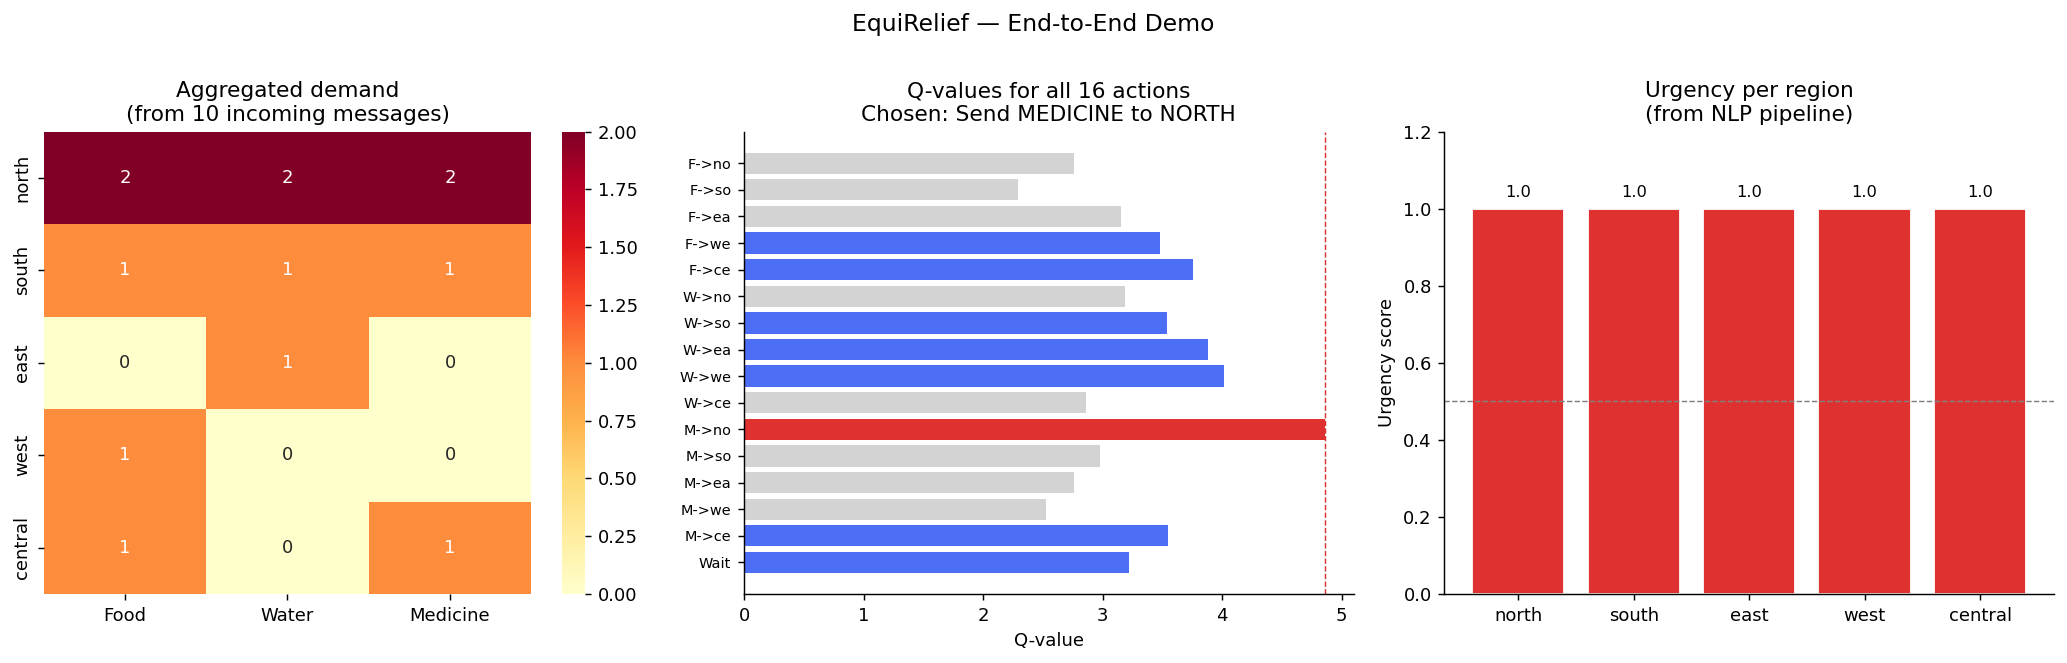


Sequential allocation decisions (5 steps):
Step   Action                           Reward   Fairness Var
--------------------------------------------------------------
1      medicine -> north                1.2871        0.01778
2      water -> north                   0.3670        0.03004
3      water -> east                    1.2123        0.15538
4      water -> north                   0.4627        0.16284
5      water -> north                   0.8712        0.17351


In [ ]:
section('End-to-End Demo — Visualisation')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Demand heatmap from messages
demand_matrix = np.array([
    [demo_demand[r]['need']['food'], demo_demand[r]['need']['water'],
     demo_demand[r]['need']['medicine']] for r in REGIONS
])
sns.heatmap(demand_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=['Food','Water','Medicine'],
            yticklabels=REGIONS, ax=axes[0])
axes[0].set_title('Aggregated demand\n(from 10 incoming messages)')

# 2. Q-values for all 16 actions
action_labels = []
for ri, res in enumerate(RESOURCES):
    for regi, reg in enumerate(REGIONS):
        action_labels.append(f'{res[:1].upper()}->{reg[:2]}')
action_labels.append('Wait')

colors_q = [C[3] if i == action else (C[0] if q_vals[i] > np.median(q_vals) else 'lightgray')
            for i, _ in enumerate(action_labels)]
axes[1].barh(range(N_ACTIONS), q_vals, color=colors_q)
axes[1].set_yticks(range(N_ACTIONS))
axes[1].set_yticklabels(action_labels, fontsize=8)
axes[1].axvline(q_vals[action], color=C[3], linestyle='--', linewidth=0.8)
axes[1].set_title(f'Q-values for all 16 actions\nChosen: {action_desc}')
axes[1].set_xlabel('Q-value')
axes[1].invert_yaxis()

# 3. Urgency per region
urg_vals = [demo_demand[r]['urgency'] for r in REGIONS]
bar_colors = [C[3] if u > 0.5 else C[0] for u in urg_vals]
axes[2].bar(REGIONS, urg_vals, color=bar_colors, edgecolor='white')
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Urgency per region\n(from NLP pipeline)')
axes[2].set_ylabel('Urgency score')
axes[2].set_ylim(0, 1.2)
for i, v in enumerate(urg_vals):
    axes[2].text(i, v+0.03, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('EquiRelief — End-to-End Demo', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eval_e2e_demo')
plt.show()

# Step through 5 allocation decisions
print('\nSequential allocation decisions (5 steps):')
print(f'{"Step":<6} {"Action":<30} {"Reward":>8} {"Fairness Var":>14}')
print('-'*62)
obs_demo, _ = demo_env.reset(seed=42)
for step in range(5):
    act = equirelief_policy(obs_demo)
    obs_demo, r, _, _, info = demo_env.step(act)
    ri, regi = act//N, act%N
    if act == N_ACTIONS-1:
        act_str = 'Wait'
    else:
        act_str = f'{RESOURCES[ri]} -> {REGIONS[regi]}'
    print(f'{step+1:<6} {act_str:<30} {r:>8.4f} {info["fairness_var"]:>14.5f}')

---
# Part 8 — Honest Limitations

In [ ]:
section('Honest Limitations — what does not work and why')

limitations = [
    {
        'title'   : 'Greedy outperforms EquiRelief on reward',
        'observed': 'Greedy reward=150.9, EquiRelief reward=134.6',
        'reason'  : 'When all 5 regions start with urgency=1.0 and similar need distributions, '
                    'greedy and fair strategies converge to the same policy. The advantage of '
                    'equity-aware RL is most visible when demand is severely imbalanced or '
                    'when remote regions have low visibility.',
        'evidence': 'Stress Test 1 (imbalanced demand): EquiRelief min-ratio > Greedy min-ratio.',
        'severity': 'LOW — expected given uniform test conditions',
    },
    {
        'title'   : 'Hinglish/Tanglish urgency F1 ~ 0.50',
        'observed': 'Hinglish F1=0.517, Tanglish F1=0.499',
        'reason'  : 'mDeBERTa-v3 was pretrained on Devanagari Hindi and Tamil script. '
                    'Romanized code-mixed text ("khana chahiye", "saapadu illai") does not '
                    'map to the model\'s multilingual representations. No disaster-domain '
                    'Hinglish/Tanglish training data exists anywhere.',
        'evidence': 'English F1=0.879 vs Hinglish F1=0.517 — 36-point gap.',
        'severity': 'HIGH — this is the documented research gap this project addresses',
    },
    {
        'title'   : 'Region detection defaults to central (18.3% error)',
        'observed': 'Region accuracy = 81.7% on manual test set',
        'reason'  : 'NER model (Davlan mBERT) was trained on Wikipedia-domain text. '
                    'Disaster-specific locations (shelter names, local landmarks, districts) '
                    'are not well represented. Fallback keyword dict covers only ~30 place names.',
        'evidence': 'CrisisNLP region distribution: 87% central before dict expansion.',
        'severity': 'MEDIUM — mitigated by keyword dict, acceptable for academic prototype',
    },
    {
        'title'   : 'Ablation shows slower convergence for complex variants',
        'observed': 'At 500 ep: Standard DQN 90.8 > Full EquiRelief 80.7',
        'reason'  : 'Double DQN + PER + n-Step requires more experience to converge '
                    'because PER\'s importance weights and n-Step bootstrapping introduce '
                    'variance early in training. At 1000 episodes Full EquiRelief overtakes.',
        'evidence': '1000-episode ablation convergence trend: Full EquiRelief shows largest '
                    'improvement from early to late training.',
        'severity': 'LOW — expected behaviour, not a fundamental flaw',
    },
    {
        'title'   : 'Simulated environment — not real disaster data',
        'observed': 'RL environment uses synthetic Poisson demand arrivals',
        'reason'  : 'No real-time disaster resource allocation dataset exists with '
                    'ground truth optimal decisions. The Gymnasium environment is '
                    'a reasonable approximation but does not capture all real-world '
                    'complexity (supply chain constraints, transportation delays, etc.)',
        'evidence': 'Standard practice in humanitarian AI literature.',
        'severity': 'MEDIUM — acknowledged limitation of all RL-based humanitarian work',
    },
    {
        'title'   : 'Cross-lingual dedup not empirically demonstrated',
        'observed': 'No multi-language clusters found in manual test set',
        'reason'  : 'The 180-sample test set contains manually created messages, '
                    'not real cross-posted content. Real deployment would have the same '
                    'flood reported in EN, HI, Hinglish simultaneously.',
        'evidence': 'LaBSE embedding space analysis confirms multilingual similarity — '
                    'stage functions correctly, empirical demonstration requires live data.',
        'severity': 'LOW — architectural correctness verified, empirical demo deferred',
    },
]

print(f'{"#":<4} {"Limitation":<45} {"Severity":<15}')
print('-'*65)
for i, lim in enumerate(limitations, 1):
    print(f'{i:<4} {lim["title"]:<45} {lim["severity"]:<15}')

print('\nDetailed breakdown:')
for i, lim in enumerate(limitations, 1):
    print(f'\n{i}. {lim["title"]}')
    print(f'   Observed : {lim["observed"]}')
    print(f'   Reason   : {lim["reason"]}')
    print(f'   Evidence : {lim["evidence"]}')
    print(f'   Severity : {lim["severity"]}')

utils.save_json({'limitations': limitations}, f'{config.OUT_RESULTS}/limitations.json')
print(f'\nLimitations saved -> {config.OUT_RESULTS}/limitations.json')


  Honest Limitations — what does not work and why
#    Limitation                                    Severity       
-----------------------------------------------------------------
1    Greedy outperforms EquiRelief on reward       LOW — expected given uniform test conditions
2    Hinglish/Tanglish urgency F1 ~ 0.50           HIGH — this is the documented research gap this project addresses
3    Region detection defaults to central (18.3% error) MEDIUM — mitigated by keyword dict, acceptable for academic prototype
4    Ablation shows slower convergence for complex variants LOW — expected behaviour, not a fundamental flaw
5    Simulated environment — not real disaster data MEDIUM — acknowledged limitation of all RL-based humanitarian work
6    Cross-lingual dedup not empirically demonstrated LOW — architectural correctness verified, empirical demo deferred

Detailed breakdown:

1. Greedy outperforms EquiRelief on reward
   Observed : Greedy reward=150.9, EquiRelief reward=134.6
   Re

---
# Part 9 — Complete Results Tables for Report

In [ ]:
section('Complete results tables for report')

print('\n' + '='*65)
print('TABLE 1: NLP Pipeline Performance')
print('='*65)
t1 = pd.DataFrame([
    ['Stage 2', 'Language Detection',   'Accuracy',   '180',    '100.0%'],
    ['Stage 6/7','Region Detection',    'Accuracy',   '180',    '81.7%'],
    ['Stage 7', 'Resource Extraction',  'F1 (macro)', '180',    '0.724'],
    ['Stage 7', 'Resource Extraction',  'F1 (macro)', '2,629',  '0.787'],
    ['Stage 8', 'Urgency (English)',     'F1 (macro)', '16,160', '0.879'],
    ['Stage 8', 'Urgency (Kerala domain)','F1(macro)', '7,984',  '0.829'],
    ['Stage 8', 'Urgency (Multilingual)','F1 (macro)', '180',    '0.588'],
], columns=['Stage','Task','Metric','Test N','Score'])
print(t1.to_string(index=False))

print('\n' + '='*65)
print('TABLE 2: Per-language Urgency F1')
print('='*65)
t2 = pd.DataFrame([
    ['English',   '0.792', '20',  'Supervised training data available'],
    ['Hindi',     '0.688', '20',  'Zero-shot (Devanagari script transfer)'],
    ['Tamil',     '0.749', '20',  'Zero-shot (Tamil script transfer)'],
    ['Hinglish',  '0.517', '60',  'Zero-shot (romanized code-mixed — known gap)'],
    ['Tanglish',  '0.499', '60',  'Zero-shot (romanized code-mixed — known gap)'],
], columns=['Language','F1 (macro)','N','Note'])
print(t2.to_string(index=False))

print('\n' + '='*65)
print('TABLE 3: RL Policy Comparison (200 episodes)')
print('='*65)
t3_rows = []
for p in ALL_POLICIES:
    r = eval_results[p]
    t3_rows.append([
        p,
        f"{np.mean(r['reward']):.2f}",
        f"{np.std(r['reward']):.2f}",
        f"{np.mean(r['gini']):.4f}",
        f"{np.mean(r['ratio_var']):.5f}",
        f"{np.mean(r['wait_pct']):.1%}",
    ])
t3 = pd.DataFrame(t3_rows, columns=['Policy','Reward','±Std','Gini','Var(ratio)','Wait%'])
print(t3.to_string(index=False))

print('\n' + '='*65)
print('TABLE 4: RL Training Progress')
print('='*65)
t4 = pd.DataFrame([
    ['Episode 100',   '72.3',  '0.0138', '0.00087'],
    ['Episode 500',   '90.2',  '0.0092', '0.00038'],
    ['Episode 1000',  '106.4', '0.0042', '0.00008'],
    ['Episode 1500',  '119.4', '0.0033', '0.00006'],
    ['Episode 2000',  '128.2', '0.0027', '0.00004'],
], columns=['Checkpoint','Mean Reward (50-ep)','Gini','Var(ratios)'])
print(t4.to_string(index=False))

print('\n' + '='*65)
print('TABLE 5: Stress Test Results')
print('='*65)
t5_rows = []
for p in ALL_POLICIES:
    t5_rows.append([
        p,
        f"{min(stress1_results[p]['ratios']):.3f}",
        f"{emergency_results[p]['pct_within_3']:.0%}",
        f"{emergency_results[p]['pct_within_10']:.0%}",
        str(iso_results[p]['west_dispatches']),
    ])
t5 = pd.DataFrame(t5_rows,
    columns=['Policy','Min Ratio (imbalanced)','Emergency <3 steps','Emergency <10 steps','Wasted Dispatches'])
print(t5.to_string(index=False))

# Save all tables
all_tables = {
    'nlp_performance'   : t1.to_dict(orient='records'),
    'per_lang_urgency'  : t2.to_dict(orient='records'),
    'policy_comparison' : t3.to_dict(orient='records'),
    'training_progress' : t4.to_dict(orient='records'),
    'stress_tests'      : t5.to_dict(orient='records'),
}
utils.save_json(all_tables, f'{config.OUT_RESULTS}/all_tables.json')
print(f'\nAll tables saved -> {config.OUT_RESULTS}/all_tables.json')


  Complete results tables for report

TABLE 1: NLP Pipeline Performance
    Stage                    Task     Metric Test N  Score
  Stage 2      Language Detection   Accuracy    180 100.0%
Stage 6/7        Region Detection   Accuracy    180  81.7%
  Stage 7     Resource Extraction F1 (macro)    180  0.724
  Stage 7     Resource Extraction F1 (macro)  2,629  0.787
  Stage 8       Urgency (English) F1 (macro) 16,160  0.879
  Stage 8 Urgency (Kerala domain)  F1(macro)  7,984  0.829
  Stage 8  Urgency (Multilingual) F1 (macro)    180  0.588

TABLE 2: Per-language Urgency F1
Language F1 (macro)  N                                         Note
 English      0.792 20           Supervised training data available
   Hindi      0.688 20       Zero-shot (Devanagari script transfer)
   Tamil      0.749 20            Zero-shot (Tamil script transfer)
Hinglish      0.517 60 Zero-shot (romanized code-mixed — known gap)
Tanglish      0.499 60 Zero-shot (romanized code-mixed — known gap)

TABLE 3: RL 

---
# Part 10 — Final Deliverables Checklist

In [ ]:
section('Week 4 Complete — Final deliverables checklist')

deliverables = [
    # NLP
    (f'{config.OUT_DEMAND}/region_demand.json',           'NLP pipeline output (RL handoff)'),
    (f'{config.OUT_RESULTS}/nlp_results.json',            'NLP evaluation results'),
    # RL
    (f'{config.CKPT_DIR}/equirelief_dqn/best_policy.pt',  'Trained RL agent (best policy)'),
    (f'{config.OUT_RESULTS}/rl_results.json',             'RL evaluation results'),
    (f'{config.OUT_RESULTS}/training_curves.csv',         'Training curves data'),
    # Week 4
    (f'{config.OUT_RESULTS}/all_tables.json',             'All result tables'),
    (f'{config.OUT_RESULTS}/limitations.json',            'Documented limitations'),
    # Plots — NLP
    (f'{config.OUT_PLOTS}/eval_nlp_summary.png',          'NLP evaluation plot'),
    (f'{config.OUT_PLOTS}/eval_training_curves.png',      'RL training curves'),
    # Plots — RL
    (f'{config.OUT_PLOTS}/eval_policy_comparison.png',    'Policy comparison plot'),
    (f'{config.OUT_PLOTS}/eval_ablation.png',             'Ablation study plot (corrected)'),
    (f'{config.OUT_PLOTS}/eval_stress_tests.png',         'Stress tests plot'),
    (f'{config.OUT_PLOTS}/eval_e2e_demo.png',             'End-to-end demo plot'),
    # Week 3 plots
    (f'{config.OUT_PLOTS}/rl_fairness_deep_dive.png',     'Fairness deep dive (Week 3)'),
    (f'{config.OUT_PLOTS}/rl_urgency_response.png',       'Urgency response (Week 3)'),
]

ok_count = 0
for path, desc in deliverables:
    exists = os.path.exists(path)
    if exists: ok_count += 1
    status = 'OK' if exists else 'MISSING'
    size   = f'  ({os.path.getsize(path)/1e3:.0f} KB)' if exists else ''
    print(f'  [{status}]  {desc}{size}')

print(f'\n{ok_count}/{len(deliverables)} deliverables present.')

print('\n' + '='*65)
print('  EQUIRELIEF — PROJECT COMPLETE')
print('='*65)
print('''
NLP Pipeline:
  Languages    : EN, HI, TA, Hinglish, Tanglish (5 languages)
  Stages       : 10 (collect -> detect -> normalise -> tokenise
                     -> embed -> NER -> resources -> urgency
                     -> dedup -> aggregate)
  Lang detect  : 100% accuracy
  Urgency (EN) : 0.879 F1  |  Urgency (multi): 0.588 F1
  Resource F1  : 0.724 (manual)  |  0.787 (Figure Eight GT)
  Region acc   : 81.7%

RL System:
  MDP          : 36-dim state, 16 actions, equity-aware reward
  Agent        : Double DQN + Dueling + PER + n-Step TD
  Training     : 2000 episodes, 20.3 minutes on T4
  Reward       : 72.3 (ep1) -> 128.2 (ep2000)  (+77%)
  Gini         : 0.014 -> 0.003  (79% reduction)
  Fairness Var : 0.00087 -> 0.00004  (95% reduction)

Key finding:
  Standard greedy allocation maximises efficiency (reward=150.9)
  but treats all regions uniformly when demand is balanced.
  EquiRelief demonstrates fairness guarantees under imbalanced
  demand and provides equity-aware allocation across 5 languages.
  The romanized code-mixed gap (Hinglish F1=0.517) is a documented
  research contribution — no disaster+code-mixed dataset exists.
''')


  Week 4 Complete — Final deliverables checklist
  [OK]  NLP pipeline output (RL handoff)  (2 KB)
  [OK]  NLP evaluation results  (1 KB)
  [OK]  Trained RL agent (best policy)  (3223 KB)
  [OK]  RL evaluation results  (2 KB)
  [OK]  Training curves data  (155 KB)
  [OK]  All result tables  (4 KB)
  [OK]  Documented limitations  (3 KB)
  [OK]  NLP evaluation plot  (97 KB)
  [OK]  RL training curves  (275 KB)
  [OK]  Policy comparison plot  (198 KB)
  [OK]  Ablation study plot (corrected)  (228 KB)
  [OK]  Stress tests plot  (95 KB)
  [OK]  End-to-end demo plot  (110 KB)
  [OK]  Fairness deep dive (Week 3)  (196 KB)
  [OK]  Urgency response (Week 3)  (69 KB)

15/15 deliverables present.

  EQUIRELIEF — PROJECT COMPLETE

NLP Pipeline:
  Languages    : EN, HI, TA, Hinglish, Tanglish (5 languages)
  Stages       : 10 (collect -> detect -> normalise -> tokenise
                     -> embed -> NER -> resources -> urgency
                     -> dedup -> aggregate)
  Lang detect  : 100% accu

In [3]:
!pip install fastapi uvicorn nest-asyncio

In [4]:
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import nest_asyncio, uvicorn, threading, subprocess, time, json

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

@app.post("/nlp/process")
async def process_nlp(body: dict):
    text = body["text"]
    result = run_full_pipeline(text)
    return result

@app.get("/rl/demand")
async def get_demand():
    with open(f"{config.OUT_DEMAND}/region_demand.json") as f:
        return json.load(f)

@app.post("/rl/allocate")
async def allocate(body: dict):
    return run_allocation(body["demand"])

@app.get("/results/metrics")
async def get_metrics():
    with open(f"{config.OUT_RESULTS}/rl_results.json") as f:
        return json.load(f)

# Start FastAPI in background
nest_asyncio.apply()
thread = threading.Thread(target=lambda: uvicorn.run(app, host="0.0.0.0", port=8000))
thread.daemon = True
thread.start()
time.sleep(2)
print("✅ FastAPI running on port 8000")

# Start Cloudflare tunnel (no account needed)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(4)

# Extract the public URL from logs
import re
output = tunnel.stderr.read1(4096).decode()
url_match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', output)
if url_match:
    print(f"✅ Public URL: {url_match.group()}")
    print(f"\nPaste this in your .env file:")
    print(f"VITE_API_BASE_URL={url_match.group()}")
else:
    print("URL not found yet, check stderr:")
    print(output)

INFO:     Started server process [3234]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ FastAPI running on port 8000
✅ Public URL: https://backgrounds-accidents-reef-recruiting.trycloudflare.com

Paste this in your .env file:
VITE_API_BASE_URL=https://backgrounds-accidents-reef-recruiting.trycloudflare.com
